# Tratamento de Dados e Modelagem da Tensão de Saída de um Inversor Trifásico

Grupo: Cleyton Maciel, Daniel Naime e Thales Tobias

## <a id="ref"></a>Referências

**Referência do Artigo**:
M. Stender, O. Wallscheid and J. Böcker, "Data Set Description: Three-Phase IGBT Two-Level Inverter for Electrical Drives," Paderborn University, Germany, 2020.

**Referência do Dataset**: M. Stender, O. Wallscheid and J. Böcker, "Three-phase IGBT two-level inverter for electrical drives (data)," Kaggle, 2020. Disponível em: https://www.kaggle.com/stender/inverter-data-set.


## <a id="context"></a> Contextualização 

  Motores de indução trifásicos são os responsáveis majoritários pela força motriz industrial. Sendo assim, técnicas de acionamento e controle são essenciais e extremamente relevantes para contornar a dificuldade de manejar seu comportamento, por exempo, de variáveis como velocidade, torque, resposta transitória e estabilidade a variações de carga.
  
  Dentre as técnicas de acionamentos, o Controle de Campo Vetorial (Field-Oriented Control) é empregado para modelar motores de indução visando separar as componentes responsáveis por gerar torque e excitar o campo magnético da máquina, com o objetivo de facilitar a obtenção das respostas desejadas de operação.

  A técnica consiste em construir uma malha fechada em que as variáveis de controle (sinal que será usado para modular o chaveameto do inversor) do método FOC são as tensões de saída do inversor que alimenta o motor de indução. Como mostrado na **[Figura 1](#malha_controle)**
  

<figure id="malha_controle" style="text-align: center;">
    <img src="Esquema_Inversor.png" width="400" style="display: block; margin: 0 auto;">
    <figcaption>
        <b>Figura 1:</b> Esquema da Malha de Controle (Retirado de STENDER et al., 2020).
    </figcaption>
</figure>

Entretanto, os sensores para medir as tensões de saída do inversor são caros e consequentemente é optado por desenvolver modelos que estimem essa variável, com o intuito de viabilizar economicamente o projeto. Sendo assim o objetivo desse trabalho é desenvolver um modelo para estimar as leituras reais através de outros sensores disponíveis, visando a diminuição do custo total sem perda expressiva do controle desejado. 




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/home/cgpm/Documentos/Datasets/inversor/archive/Inverter Data Set.csv")

### Modelagem Tradicional

A modelagem analítica tradicional de inversores de dois níveis enfrenta obstáculos significativos para aplicações de controle em tempo real:

>* **Efeitos Não Lineares Complexos:** Fenômenos como o tempo de intertravamento , componentes parasitas e o grampeamento de corrente zero distorcem a tensão de saída
>* **Inviabilidade Computacional:** Simular esses efeitos com precisão exigiria passos de tempo na escala de nanossegundos
>* **Incerteza de Parâmetros:** Existem variações de fabricação entre as fases e dados insuficientes em manuais técnicos para uma parametrização exata

<a id="equacao_I"></a>

Para quantificar essas não linearidades, utilizamos o modelo de um **Inversor Ideal** como linha de base. Este modelo ignora quedas de tensão e tempos de comutação, definindo a tensão média de fase ($\overline{u}$) como:

$$
\begin{equation}
\overline{u}_{,x,k-1} = d_{x,k-2} \cdot u_{dc,k-2}
\tag{\textbf{Equação I:} Modelo Simplificado}
\end{equation}
$$

**Onde:**
$d_{x,k-2}$: Ciclo de trabalho (*duty cycle*) aplicado e $u_{dc,k-2}$: Tensão medida no barramento CC.

>O **erro de simplificação** plotado a seguir representa a diferença entre a tensão real medida pelos sensores e este valor ideal.

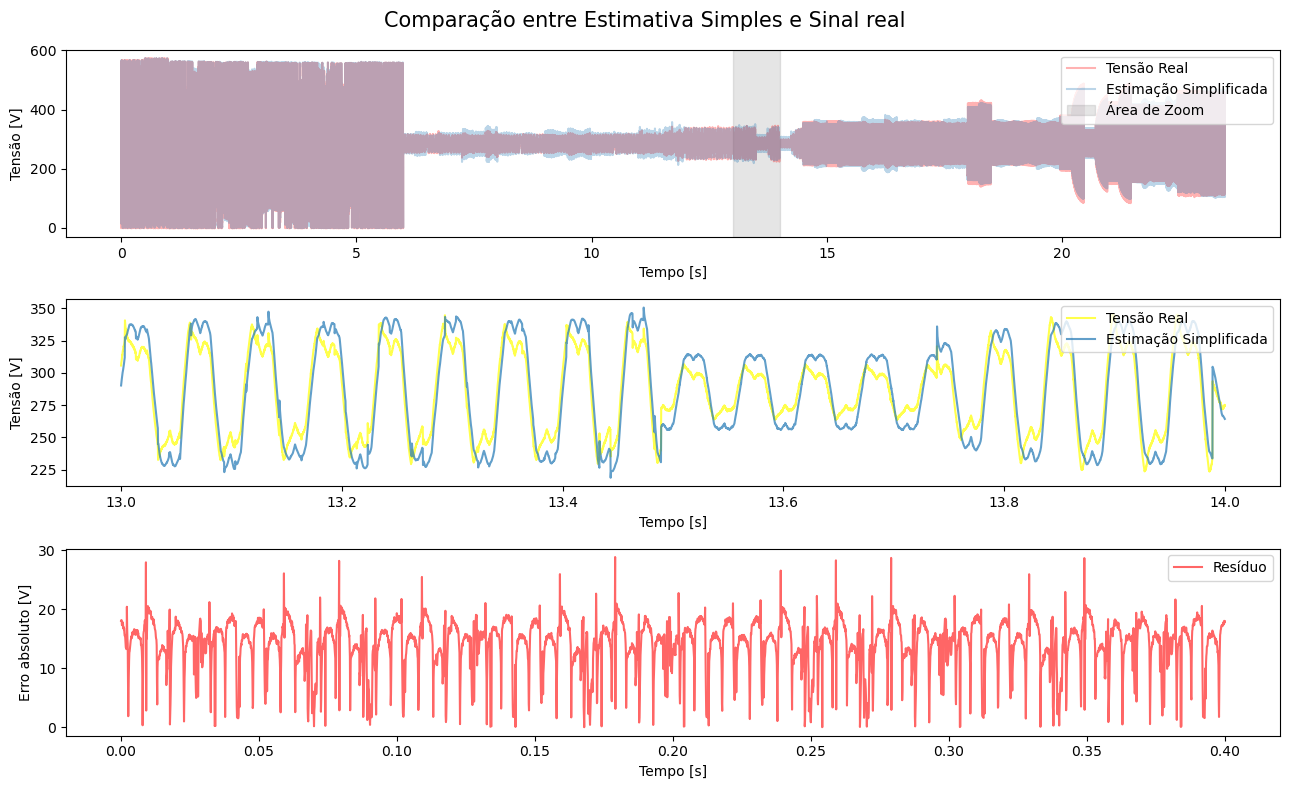

In [3]:
f = 10e3
T_sample = 1/f

fig, ax = plt.subplots(3, 1, figsize=(13, 8))
a = 130000
b = 140000

tempo = np.arange(0, len(df) * T_sample, T_sample)

df['timestamp'] = tempo

plt.suptitle("Comparação entre Estimativa Simples e Sinal real", fontsize = 15)

ax[0].plot(df['timestamp'], df['u_a_k-1'], alpha=0.3, color="red", label="Tensão Real")
ax[0].plot(df['timestamp'], (df['d_a_k-2'] * df['u_dc_k-2']), alpha=0.3, label="Estimação Simplificada")
ax[0].set_xlabel("Tempo [s]")
ax[0].set_ylabel("Tensão [V]")

ax[0].axvspan(df['timestamp'][a], df['timestamp'][b], color='gray', alpha=0.2, label="Área de Zoom")
ax[0].legend(loc="upper right", fontsize=10)


ax[1].plot(df['timestamp'][a:b], df[a:b]['u_a_k-1'], alpha=0.7, color="yellow", label="Tensão Real")
ax[1].plot(df['timestamp'][a:b], (df[a:b]['d_a_k-2'] * df[a:b]['u_dc_k-2']), alpha=0.7, label="Estimação Simplificada")
ax[1].set_xlabel("Tempo [s]")
ax[1].set_ylabel("Tensão [V]")
ax[1].legend(loc="upper right", fontsize=10)


ax[2].plot(df['timestamp'][:4000], np.abs((df['u_a_k-1'])-(df['d_a_k-2']*df['u_dc_k-2']))[:4000], alpha=0.6, color="red", label="Resíduo")
ax[2].set_xlabel("Tempo [s]")
ax[2].set_ylabel("Erro absoluto [V]")
ax[2].legend(loc="upper right", fontsize=10)
plt.savefig("Erro.png")

plt.tight_layout()

## Tratamento Inicial dos Dados


### <a id = "idi_ses"></a>Identificando e Separando Sessões

In [4]:
index = (np.where(df["i_a_k"].values != np.append(df["i_a_k-1"].values, [0])[1:]))[0]+1
print('-'*25,"Índice de amostra que identifica sessões diferentes",'-'*25,'\n\n', index,'\n')
print('-'*100)
print(" "*40 ,f"No total, temos {(len(index))} sessões")
print('-'*100)
index2 = (np.where(df["i_a_k"][:-1].values == df["i_a_k"][1:].values))[0]

print(f"No total, temos {(len(index2))} pontos repetidos, ou seja, há possibilidade dos dados estarem superamostrados")


pontos = np.append(0,index)
sessoes = [df.iloc[pontos[i]:pontos[i+1]] for i in range(len(pontos)-1)]

------------------------- Índice de amostra que identifica sessões diferentes ------------------------- 

 [  4996   9992  14988  19984  24980  29976  34972  39968  44964  49960
  54956  59952  64948  69944  74940  79936  84932  89928  94924  99920
 104916 109912 114908 119904 124900 129896 134892 139888 144884 149880
 154876 159872 164868 169864 174860 179856 184852 185989 189563 194559
 199555 204551 209547 214543 219539 224535 229531 234527] 

----------------------------------------------------------------------------------------------------
                                         No total, temos 48 sessões
----------------------------------------------------------------------------------------------------
No total, temos 1702 pontos repetidos, ou seja, há possibilidade dos dados estarem superamostrados


>A lógica empregada indentificou <strong>48 interrupções</strong>. Esse teste foi realizado em todas as variáveis que contém o histórico e comparado com os saltos em velocidade. 

## Modelos Caixa Preta

Há dois modelos de regressão presentes em nosso sistema, ambos com múltiplas entradas:

> #### **1** O Primeiro Modelo é uma representação das tensões de saída do inversor que alimentam o motor através de entradas puramente exógenas
$$\mathbf{X} = 
\begin{bmatrix}
d_{x(k-3)} \\ d_{x(k-2)} \\ i_{x(k-1)} \\ i_{x(k)} \\ u_{dc(k-1)} \\ u_{dc(k)} \\
\end{bmatrix}
\qquad \mathbf{Ŷ} = \begin{bmatrix} \bar{u}_{a(k-1)} \\ \bar{u}_{b(k-1)} \\ \bar{u}_{c(k-1)} \end{bmatrix}$$

> #### **2** O Segundo Modelo é uma representação dos Ciclos de Trabalho que geram as tensões estimadas no primeiro Modelo. Esse modelo é caracterizado como autorregressivo visto que:

$$d_{a(k-2)} + T_{amostragem} = d_{x(k-3)}$$ 

$$\mathbf{X} = 
\begin{bmatrix}
\bar{u}_{x(k-1)} \\ d_{x(k-3)} \\ i_{x(k-3)} \\ i_{x(k-2)} \\ u_{dc(k-3)} \\ u_{dc(k-2)}
\end{bmatrix}
\qquad \mathbf{\hat{Y}} = \begin{bmatrix} d_{a(k-2)} \\ d_{b(k-2)} \\ d_{c(k-2)} \end{bmatrix}$$

$\text{Em que } x \in \{a,b,c\}$



### Métricas de Performance

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

A métrica $R²$ no sistema apresentado não representa de forma eficiente as melhorias do modelo. Pois relaciona o resíduo gerado do modelo em relação a média. Ou seja, o denominador representa o erro máximo aceitável, pois um erro maior ocasionaria na solução de selecionar diretamente a média das amostras.

Uma análise alternativa pode ser realizada ao comparar o modelo com a <a href ="#equacao_I">equação simplificada</a>:

$$R^R = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - (d_{x,k-2} \cdot u_{dc,k-2}))^2}$$

Na expressão acima, comparamos os modelos com a Equação Simplificada. 

Se o $R^R$: 
* For maior que 0, o  modelo encontrou padrões (não linearidades, perdas de comutação, ou efeitos de temperatura) que a equação simples ignora.
* For menor ou igual a 0, o modelo não conseguiu superar a equação simplificada.

In [5]:
def ML_comp_simples (y_teste, y_pred, y_simples):
    RR = 1 - (np.sum((y_teste.values-y_pred)**2))/(np.sum((y_teste.values-y_simples.values)**2))
    return RR

## Abordagens de Modelagem

Ao lidar com sistemas físicos complexos, como inversores elétricos operando em diferentes regimes (variações de frequência, carga e velocidade), a escolha da arquitetura do modelo define o teto de precisão do projeto. As duas principais abordagens analisadas durante a experimentação são descritas abaixo.

### Modelo Único (Global)

Esta estratégia consiste em concatenar todos os dados de diferentes sessões e regimes operacionais em um único *dataset* e treinar um único algoritmo para aprender o comportamento geral do sistema.

**Vantagens:**
>* **Simplicidade:** Apenas um modelo é criado e usado para inferência.
>* **Volume Estatístico:** O algoritmo tem acesso à variância completa dos dados simultaneamente, aproveitando o poder do grande volume de informações para evitar *overfitting* generalizado.
>* **Interpolação:** Modelos robustos conseguem generalizar comportamentos para dados inéditos que caiam "entre" dois regimes conhecidos.

**Desvantagens:**
>* **Vulnerabilidade ao Paradoxo de Simpson:** Em sistemas não-lineares, forçar um modelo linear a traçar uma "média" entre fenômenos físicos divergentes resulta em uma linha de tendência imprecisa, prejudicando o desempenho global.
>* **Gargalo Computacional:** Para que um único modelo capture as micro-dinâmicas de 48 regimes diferentes, seria necessário o uso de algoritmos altamente complexos. Esses algoritmos são, na maioria das vezes, inviáveis para inferência em sistemas embarcados operando em altíssima frequência (ex: controle a 10 kHz).



### Múltiplos Modelos com Direcionamento (Mistura de Especialistas)

Também conhecida como *Mixture of Experts* (MoE) ou *Piecewise Modeling*, esta abordagem divide o problema. Um classificador (ou métrica de roteamento) identifica o regime de operação e direciona os dados do sensor para um **Modelo Especialista**, treinado exclusivamente com o escopo daquele regime.

**Vantagens:**
>* **Alta Fidelidade Física:** Permite isolar não-linearidades do *hardware* (como tempos de intertravamento e correntes parasitas), garantindo um $R^2$ excepcional, já que cada modelo foca apenas na dinâmica de sua respectiva sessão.
>* **Otimização para Hardware Restrito:** Como o escopo de cada especialista é estreito e linear, o modelo se resume a uma matriz minúscula de pesos matemáticos. Isso consome apenas alguns Kilobytes de memória Flash e roda em frações de microssegundos no microcontrolador.
>* **Aumento de Confiabilidade:** Caso ocorra degradação de desempenho em algum dos modelos, a manutenção é direcionada apenas ao modelo daquela sessão específica, sem o risco de prejudicar o comportamento do sistema nas outras sessões.

**Desvantagens:**
>* **Necessidade de Orquestração:** Exige a implementação de um roteador lógico. Se o sistema embarcado classificar o regime de forma equivocada, a inferência será enviada ao modelo errado, causando erros catastróficos de previsão.
>* **Manutenção de Artefatos:** O *pipeline* de dados precisa ser capaz de gerenciar, treinar e exportar dezenas de vetores de pesos estruturados, aumentando a complexidade do script base.
>* **Fragmentação dos Dados:** A divisão do *dataset* reduz consideravelmente a quantidade de amostras de treinamento por sessão, exigindo cuidado redobrado na avaliação de regimes mais curtos ou raros.
>* **Atraso na Inferência:** Por ser necessário classificar o regime para posteriormente realizar a inferência, a extração de features para realizar o direcionamento ao modelo compromete a responsividade. Inviabilizando a aplicações em regimes altamente dinâmicos.

In [6]:
cor_val_real = 'black'
cor_val_simples = 'red'
cor_val_indiv_RL = 'blue'
cor_val_global_RL = 'green'
cor_val_global_NL = 'orange'
cor_val_global_RF = 'purple'



## Regressão Linear Múltipla sem Regularização 
Para o método de Regressãp Linear Múltipla
$$\mathbf{Ŷ}=\beta_0+\mathbf{\beta_i X}$$
Devemos obter os parâmetros $\beta_i$  levem a $\left( min \sum\epsilon = |y-ŷ|\right)$ e consequentemente em uma melhor representação da saída desejada 

#### Bibliotecas

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

#### Filtrando as colunas que serão utilizadas como entradas e saídas para o modelo

In [8]:
X = [df.drop(columns=['u_a_k-1', 'u_b_k-1', 'u_c_k-1', 'n_k']) for df in sessoes]
y = [df[['u_a_k-1', 'u_b_k-1', 'u_c_k-1']] for df in sessoes]

modelos = {}

#### Criando Dicionário

Um dicionário foi criado para centralizar os modelos e as métricas para serem utilizadas nas comparações. a seguinte estrutura está presente no dicionário:

In [9]:
from collections import defaultdict


def dicionario():
    return defaultdict(dicionario)

modelos = dicionario()

### Modelo Único (Global)

#### Concatenando as sessões de treinamento

In [10]:
lista_X_train = []
lista_y_train = []
lista_X_test = []
lista_y_test = []

dados_modelo = {'X_treino': [], 
                'y_treino': [],
                'X_teste': [],
                'y_teste':[]
}

for a in range(48):
    X_train_sessao, X_test_sessao, y_train_sessao, y_test_sessao = train_test_split(
        X[a], y[a], test_size=0.3, shuffle=False
    )
    lista_X_train.append(X_train_sessao)
    lista_y_train.append(y_train_sessao)
    lista_X_test.append(X_test_sessao)
    lista_y_test.append(y_test_sessao)

X_train_global = pd.concat(lista_X_train, ignore_index=True)
y_train_global = pd.concat(lista_y_train, ignore_index=True)

print("Dimensão de Treinamento do Modelo global:", X_train_global.shape)

dados_modelo['X_treino'] = lista_X_train
dados_modelo['y_treino'] = lista_y_train
dados_modelo['X_teste'] = lista_X_test
dados_modelo['y_teste'] = lista_y_test



Dimensão de Treinamento do Modelo global: (164158, 23)


#### Etapa de Treinamento

In [11]:
from sklearn.metrics import mean_absolute_error

modelos.setdefault('RL', {})

modelo_global_RL = LinearRegression().fit(X_train_global, y_train_global)

num_sessoes = len(lista_X_test)
RR_sessao = np.zeros((num_sessoes, 3))
MAE_sessao = np.zeros((num_sessoes, 3))

y_simples = {'A': [], 'B': [], 'C': []}


for a in range(num_sessoes):
    X_test_atual = lista_X_test[a]
    y_test_atual = lista_y_test[a]
    
    
    y_pred = modelo_global_RL.predict(X_test_atual)
    
    
    simples_A = X_test_atual['u_dc_k-2'] * X_test_atual['d_a_k-2']
    simples_B = X_test_atual['u_dc_k-2'] * X_test_atual['d_b_k-2']
    simples_C = X_test_atual['u_dc_k-2'] * X_test_atual['d_c_k-2']
    
    y_simples['A'].append(simples_A)
    y_simples['B'].append(simples_B)
    y_simples['C'].append(simples_C)
    
    # Preenchendo a matriz de RR (Linha = Sessão, Coluna = Fase A, B, C)
    RR_sessao[a, 0] = ML_comp_simples(y_test_atual['u_a_k-1'], y_pred[:, 0], simples_A)
    RR_sessao[a, 1] = ML_comp_simples(y_test_atual['u_b_k-1'], y_pred[:, 1], simples_B)
    RR_sessao[a, 2] = ML_comp_simples(y_test_atual['u_c_k-1'], y_pred[:, 2], simples_C)

    # Preenchendo a matriz de MAE (Linha = Sessão, Coluna = Fase A, B, C)
    MAE_sessao[a, 0] = mean_absolute_error(y_test_atual['u_a_k-1'], y_pred[:, 0])
    MAE_sessao[a, 1] = mean_absolute_error(y_test_atual['u_b_k-1'], y_pred[:, 1])
    MAE_sessao[a, 2] = mean_absolute_error(y_test_atual['u_c_k-1'], y_pred[:, 2])

# Calculando as médias
RR_medias = np.mean(RR_sessao, axis=0)   
MAE_medias = np.mean(MAE_sessao, axis=0) 

# Exibindo os resultados
print("-" * 34, "Considerando os Dados de cada Sessão com 1 Modelo Global", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {RR_medias[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {RR_medias[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {RR_medias[2]:.4f}")
print("-" * 126)
print(f"{' ' * 40} Média MAE das sessões da Fase A: {MAE_medias[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {MAE_medias[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {MAE_medias[2]:.4f}")
print("-" * 126)

# Estruturando o dicionário 
modelos['RL']['Global'] = {
    'Modelo': modelo_global_RL,
    'RR_sessao': RR_sessao,
    'RR_Geral_A': RR_medias[0],
    'RR_Geral_B': RR_medias[1],
    'RR_Geral_C': RR_medias[2],
    'MAE_sessao': MAE_sessao,
    'MAE_Geral_A': MAE_medias[0],
    'MAE_Geral_B': MAE_medias[1],
    'MAE_Geral_C': MAE_medias[2]
}

---------------------------------- Considerando os Dados de cada Sessão com 1 Modelo Global ----------------------------------
                                         Média RR das sessões da Fase A: 0.8453
                                         Média RR das sessões da Fase B: 0.8443
                                         Média RR das sessões da Fase C: 0.8314
------------------------------------------------------------------------------------------------------------------------------
                                         Média MAE das sessões da Fase A: 4.6082
                                         Média MAE das sessões da Fase B: 4.6902
                                         Média MAE das sessões da Fase C: 4.6651
------------------------------------------------------------------------------------------------------------------------------


In [12]:
dados_modelo['y_simples_A'] = y_simples['A']
dados_modelo['y_simples_B'] = y_simples['B']
dados_modelo['y_simples_C'] = y_simples['C']

### Modelos com Direcionamento 

#### Etapa de Treinamento

In [13]:
modelos.setdefault('RL', {})

num_sessoes = len(X) 

# Prepara as matrizes e listas para os resultados
RR_sessao = np.zeros((num_sessoes, 3))
MAE_sessao = np.zeros((num_sessoes, 3))
modelos_independentes_RL = []
previsoes_por_sessao = [] 

# Loop pelas sessões 
for a in range(num_sessoes):
    X_train, X_test, y_train, y_test = train_test_split(X[a], y[a], test_size=0.3, shuffle=False)
    
    # Treina o modelo específico desta sessão
    modelo_sessao = LinearRegression().fit(X_train, y_train)
    modelos_independentes_RL.append(modelo_sessao) 
    
    # Previsão
    y_pred = modelo_sessao.predict(X_test)
    previsoes_por_sessao.append(y_pred)
    
    # Preenchendo a matriz de RR
    RR_sessao[a, 0] = ML_comp_simples(y_test['u_a_k-1'], y_pred[:, 0], dados_modelo['y_simples_A'][a])
    RR_sessao[a, 1] = ML_comp_simples(y_test['u_b_k-1'], y_pred[:, 1], dados_modelo['y_simples_B'][a])
    RR_sessao[a, 2] = ML_comp_simples(y_test['u_c_k-1'], y_pred[:, 2], dados_modelo['y_simples_C'][a])

    # Preenchendo a matriz de MAE
    MAE_sessao[a, 0] = mean_absolute_error(y_test['u_a_k-1'], y_pred[:, 0])
    MAE_sessao[a, 1] = mean_absolute_error(y_test['u_b_k-1'], y_pred[:, 1])
    MAE_sessao[a, 2] = mean_absolute_error(y_test['u_c_k-1'], y_pred[:, 2])

# Calculando as médias
RR_medias = np.mean(RR_sessao, axis=0)
MAE_medias = np.mean(MAE_sessao, axis=0)

# Exibindo os resultados
print("-" * 34, "Considerando os Dados de cada Sessão (Modelos Individuais)", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {RR_medias[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {RR_medias[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {RR_medias[2]:.4f}")
print("-" * 126)
print(f"{' ' * 40} Média MAE das sessões da Fase A: {MAE_medias[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {MAE_medias[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {MAE_medias[2]:.4f}")
print("-" * 126)


modelos['RL']['Individual'] = {
    'Modelos': modelos_independentes_RL,  # Guardando a lista com os 48 modelos treinados
    'Previsoes': previsoes_por_sessao,    
    'RR_sessao': RR_sessao,               
    'RR_Geral_A': RR_medias[0],
    'RR_Geral_B': RR_medias[1],
    'RR_Geral_C': RR_medias[2],
    'MAE_sessao': MAE_sessao,             
    'MAE_Geral_A': MAE_medias[0],
    'MAE_Geral_B': MAE_medias[1],
    'MAE_Geral_C': MAE_medias[2]
}

---------------------------------- Considerando os Dados de cada Sessão (Modelos Individuais) ----------------------------------
                                         Média RR das sessões da Fase A: 0.9251
                                         Média RR das sessões da Fase B: 0.9261
                                         Média RR das sessões da Fase C: 0.9221
------------------------------------------------------------------------------------------------------------------------------
                                         Média MAE das sessões da Fase A: 2.7883
                                         Média MAE das sessões da Fase B: 2.7613
                                         Média MAE das sessões da Fase C: 2.7461
------------------------------------------------------------------------------------------------------------------------------


#### Valores para os Gráficos

In [14]:
# Sessão que será utilizada para comparar o desempenho dos modelos
sessao_teste = 24

# Dados de entrada e tempo
X_test_val = dados_modelo['X_teste'][sessao_teste]
timestamp = X_test_val['timestamp'].values

modelo_global_RL = modelos['RL']['Global']['Modelo']
modelo_indiv_RL = modelos['RL']['Individual']['Modelos'][sessao_teste]

pred_global_RL = modelo_global_RL.predict(X_test_val)
pred_indiv_RL = modelo_indiv_RL.predict(X_test_val)
    
# Fase A
y_teste_A_val = dados_modelo['y_teste'][sessao_teste]['u_a_k-1'].values
y_pred_A_indiv_RL_val = pred_indiv_RL[:, 0]
y_pred_A_global_RL_val = pred_global_RL[:, 0]
y_simples_A_val = dados_modelo['y_simples_A'][sessao_teste]

# Fase B
y_teste_B_val = dados_modelo['y_teste'][sessao_teste]['u_b_k-1'].values
y_pred_B_indiv_RL_val = pred_indiv_RL[:, 1]
y_pred_B_global_RL_val = pred_global_RL[:, 1]
y_simples_B_val = dados_modelo['y_simples_B'][sessao_teste]

# Fase C
y_teste_C_val = dados_modelo['y_teste'][sessao_teste]['u_c_k-1'].values
y_pred_C_indiv_RL_val = pred_indiv_RL[:, 2]
y_pred_C_global_RL_val = pred_global_RL[:, 2]
y_simples_C_val = dados_modelo['y_simples_C'][sessao_teste]

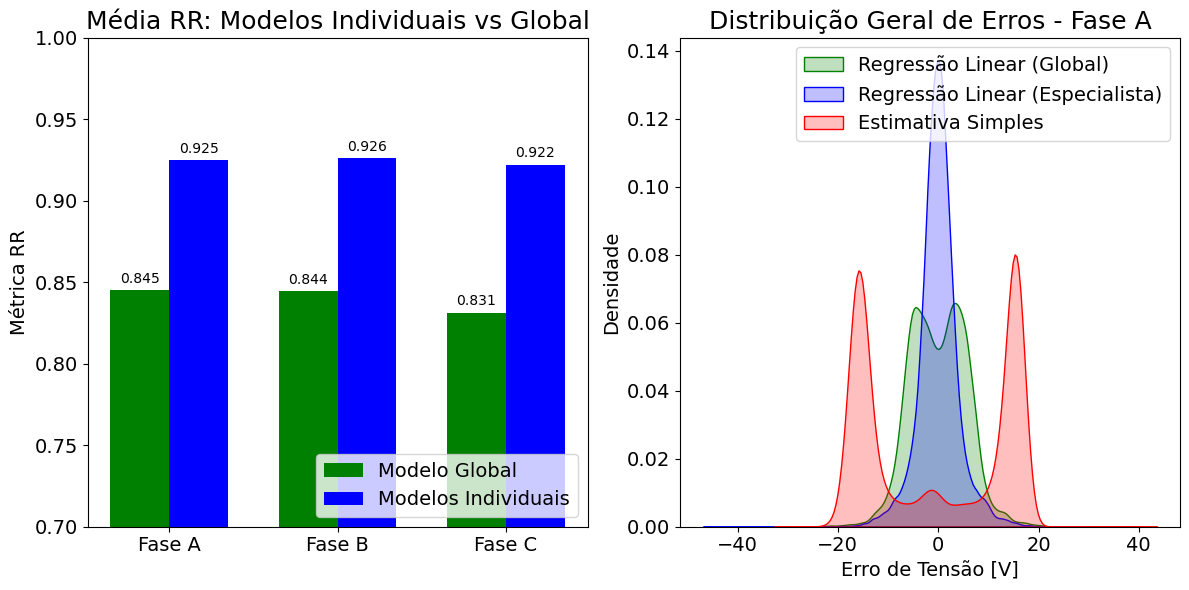

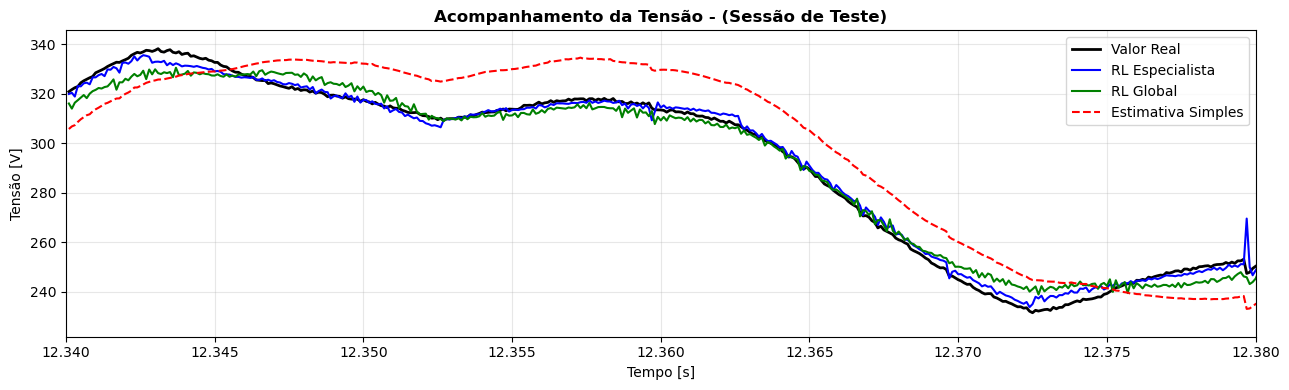

In [15]:
rr_global = [
    modelos['RL']['Global']['RR_Geral_A'],
    modelos['RL']['Global']['RR_Geral_B'],
    modelos['RL']['Global']['RR_Geral_C']
]

rr_indiv = [
    modelos['RL']['Individual']['RR_Geral_A'],
    modelos['RL']['Individual']['RR_Geral_B'],
    modelos['RL']['Individual']['RR_Geral_C']
]

erros_globais_A = []
erros_indivs_A = []
erros_simples_A = []

num_sessoes = len(dados_modelo['X_teste'])

for a in range(num_sessoes):
    y_real_fase_A = dados_modelo['y_teste'][a]['u_a_k-1'].values
    
    # Previsão Global para a sessão 'a'
    pred_global_A = modelos['RL']['Global']['Modelo'].predict(dados_modelo['X_teste'][a])[:, 0]
    
    # Previsão Individual para a sessão 'a' 
    pred_indiv_A = modelos['RL']['Individual']['Previsoes'][a][:, 0]
    
    # Estimativa simples da sessão 'a'
    pred_simples_A = dados_modelo['y_simples_A'][a]
    
    # Calculando a diferença (Erro)
    erros_globais_A.extend(y_real_fase_A - pred_global_A)
    erros_indivs_A.extend(y_real_fase_A - pred_indiv_A)
    erros_simples_A.extend(y_real_fase_A - pred_simples_A)



# Métricas e Distribuição de Erros 
x_label = ['Fase A', 'Fase B', 'Fase C']
x_indices = np.arange(len(x_label))
largura = 0.35 

fig, ax = plt.subplots(1, 2, figsize=(12,6 ))

# (RR Geral) 
ax[0].set_title("Média RR: Modelos Individuais vs Global", fontsize = 18)
ax[0].set_ylabel("Métrica RR", fontsize = 14)
ax[0].tick_params(axis='both', labelsize=14)
ax[0].set_ylim(0.7)

barras_global = ax[0].bar(x_indices - largura/2, rr_global, largura, label="Modelo Global", color=cor_val_global_RL)
barras_indiv = ax[0].bar(x_indices + largura/2, rr_indiv, largura, label="Modelos Individuais", color=cor_val_indiv_RL)

ax[0].set_xticks(x_indices)
ax[0].set_xticklabels(x_label)
ax[0].bar_label(barras_global, fmt='%.3f', padding=3)
ax[0].bar_label(barras_indiv, fmt='%.3f', padding=3)
ax[0].legend(loc='lower right', fontsize = 14)

# Distribuição de Erros Geral (Fase A) 
sns.kdeplot(erros_globais_A, fill=True, color=cor_val_global_RL, label="Regressão Linear (Global)", ax=ax[1])
sns.kdeplot(erros_indivs_A, fill=True, color=cor_val_indiv_RL, label="Regressão Linear (Especialista)", ax=ax[1])
sns.kdeplot(erros_simples_A, fill=True, color=cor_val_simples, label="Estimativa Simples", ax=ax[1])

ax[1].set_title("Distribuição Geral de Erros - Fase A", fontsize =18)
ax[1].set_ylabel("Densidade", fontsize =14 )
ax[1].set_xlabel("Erro de Tensão [V]", fontsize = 14)
plt.tick_params(axis='both', labelsize=14)
ax[1].legend(loc='upper right', fontsize = 14)

plt.tight_layout()

plt.savefig('RR e Dist_erro (S, L)')
plt.show()

# Predição da Tensão ao longo do tempo
plt.figure(figsize=(13, 4))
plt.title(f"Acompanhamento da Tensão - (Sessão de Teste)", fontweight='bold')

plt.plot(timestamp, y_teste_A_val, color=cor_val_real, label="Valor Real", linewidth=2)
plt.plot(timestamp, y_pred_A_indiv_RL_val, color=cor_val_indiv_RL, label='RL Especialista')
plt.plot(timestamp, y_pred_A_global_RL_val, color=cor_val_global_RL, label='RL Global')
plt.plot(timestamp, y_simples_A_val, color=cor_val_simples, label='Estimativa Simples', linestyle='--')
plt.ylabel('Tensão [V]')
plt.xlabel('Tempo [s]')
plt.xlim(12.34, 12.38)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('pred_Linear')
plt.show()


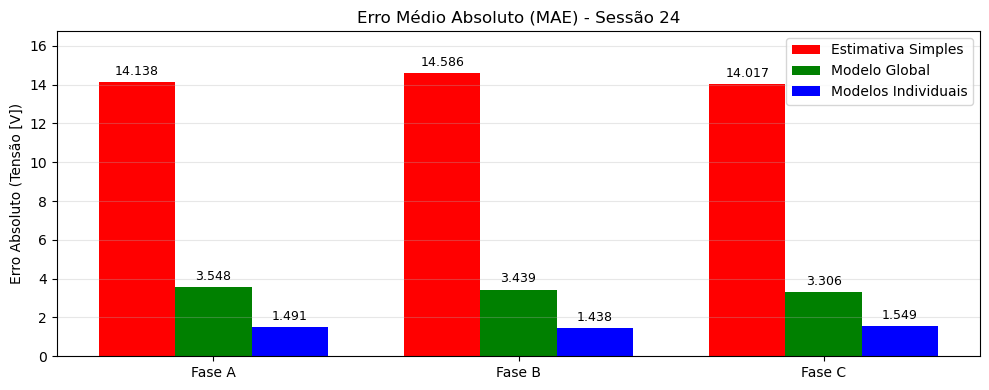

In [16]:
# Calculando os valores 
valores_MAE_simples = [
    mean_absolute_error(y_teste_A_val, y_simples_A_val),
    mean_absolute_error(y_teste_B_val, y_simples_B_val),
    mean_absolute_error(y_teste_C_val, y_simples_C_val)
]

valores_MAE_indiv_RL = [
    mean_absolute_error(y_teste_A_val, y_pred_A_indiv_RL_val),
    mean_absolute_error(y_teste_B_val, y_pred_B_indiv_RL_val),
    mean_absolute_error(y_teste_C_val, y_pred_C_indiv_RL_val)
]

valores_MAE_global_RL = [
    mean_absolute_error(y_teste_A_val, y_pred_A_global_RL_val),
    mean_absolute_error(y_teste_B_val, y_pred_B_global_RL_val),
    mean_absolute_error(y_teste_C_val, y_pred_C_global_RL_val)
]

x_label = ['Fase A', 'Fase B', 'Fase C']
x_indices = np.arange(len(x_label))
largura = 0.25 

plt.figure(figsize=(10, 4))
plt.title(f"Erro Médio Absoluto (MAE) - Sessão {sessao_teste}")
plt.ylabel("Erro Absoluto (Tensão [V])")

# Plotando as barras deslocadas
barras_simples = plt.bar(x_indices - largura, valores_MAE_simples, largura, label="Estimativa Simples", color=cor_val_simples)
barras_global  = plt.bar(x_indices, valores_MAE_global_RL, largura, label="Modelo Global", color=cor_val_global_RL)
barras_indiv   = plt.bar(x_indices + largura, valores_MAE_indiv_RL, largura, label="Modelos Individuais", color=cor_val_indiv_RL)

plt.xticks(x_indices, x_label)

# Adicionando os rótulos de dados
plt.bar_label(barras_simples, fmt='%.3f', padding=3, fontsize=9)
plt.bar_label(barras_global, fmt='%.3f', padding=3, fontsize=9)
plt.bar_label(barras_indiv, fmt='%.3f', padding=3, fontsize=9)

ymax = max(max(valores_MAE_simples), max(valores_MAE_global_RL), max(valores_MAE_indiv_RL))
plt.ylim(0, ymax * 1.15) 

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3) 
plt.tight_layout()
plt.show()

## Modelo Decimado

### Modelo Único (Global)

In [17]:
# Configuração da decimação
fator_dec = 2

modelos.setdefault('RL_dec', {})

# Modelo global com os dados decimados
modelo_global_RL_dec = LinearRegression()
modelo_global_RL_dec.fit(X_train_global[::fator_dec], y_train_global[::fator_dec])

num_sessoes = len(lista_X_test)
RR_sessao_dec = np.zeros((num_sessoes, 3))
MAE_sessao_dec = np.zeros((num_sessoes, 3)) 

# Loop pelas sessões
for a in range(num_sessoes):
    X_test_atual = lista_X_test[a]
    y_test_atual = lista_y_test[a]
    
    # Previsão com o modelo decimado
    y_pred_dec = modelo_global_RL_dec.predict(X_test_atual)
    
    # Cálculos simples
    simples_A = X_test_atual['u_dc_k-2'] * X_test_atual['d_a_k-2']
    simples_B = X_test_atual['u_dc_k-2'] * X_test_atual['d_b_k-2']
    simples_C = X_test_atual['u_dc_k-2'] * X_test_atual['d_c_k-2']

    # Preenchendo a matriz de RR
    RR_sessao_dec[a, 0] = ML_comp_simples(y_test_atual['u_a_k-1'], y_pred_dec[:, 0], simples_A)
    RR_sessao_dec[a, 1] = ML_comp_simples(y_test_atual['u_b_k-1'], y_pred_dec[:, 1], simples_B)
    RR_sessao_dec[a, 2] = ML_comp_simples(y_test_atual['u_c_k-1'], y_pred_dec[:, 2], simples_C)
    
    # Preenchendo a matriz de MAE 
    MAE_sessao_dec[a, 0] = mean_absolute_error(y_test_atual['u_a_k-1'], y_pred_dec[:, 0])
    MAE_sessao_dec[a, 1] = mean_absolute_error(y_test_atual['u_b_k-1'], y_pred_dec[:, 1])
    MAE_sessao_dec[a, 2] = mean_absolute_error(y_test_atual['u_c_k-1'], y_pred_dec[:, 2])

# Calculando as médias
RR_medias_dec = np.mean(RR_sessao_dec, axis=0)
MAE_medias_dec = np.mean(MAE_sessao_dec, axis=0)

# Exibindo os resultados
print("-" * 34, f"Dados de cada Sessão - 1 Modelo Global (Dizimado: {fator_dec})", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {RR_medias_dec[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {RR_medias_dec[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {RR_medias_dec[2]:.4f}")
print("-" * 126)

print(f"{' ' * 40} Média MAE das sessões da Fase A: {MAE_medias_dec[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {MAE_medias_dec[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {MAE_medias_dec[2]:.4f}")
print("-" * 126)

# Salvando a estrutura completa 
modelos['RL_dec']['Global'] = {
    'Modelo': modelo_global_RL_dec,
    'Fator_Decimacao': fator_dec,  
    'RR_sessao': RR_sessao_dec,
    'RR_Geral_A': RR_medias_dec[0],
    'RR_Geral_B': RR_medias_dec[1],
    'RR_Geral_C': RR_medias_dec[2],
    'MAE_sessao': MAE_sessao_dec,
    'MAE_Geral_A': MAE_medias_dec[0],
    'MAE_Geral_B': MAE_medias_dec[1],
    'MAE_Geral_C': MAE_medias_dec[2]
}

---------------------------------- Dados de cada Sessão - 1 Modelo Global (Dizimado: 2) ----------------------------------
                                         Média RR das sessões da Fase A: 0.8451
                                         Média RR das sessões da Fase B: 0.8441
                                         Média RR das sessões da Fase C: 0.8312
------------------------------------------------------------------------------------------------------------------------------
                                         Média MAE das sessões da Fase A: 4.6176
                                         Média MAE das sessões da Fase B: 4.6966
                                         Média MAE das sessões da Fase C: 4.6736
------------------------------------------------------------------------------------------------------------------------------


### Modelos com Direcionamento 

In [18]:
modelos.setdefault('RL_dec', {})

num_sessoes = len(X) 

RR_sessao_dec = np.zeros((num_sessoes, 3))
MAE_sessao_dec = np.zeros((num_sessoes, 3))
modelos_independentes_RL_dec = []
previsoes_por_sessao_dec = [] 

# Loop pelas sessões
for a in range(num_sessoes):
    X_train, X_test, y_train, y_test = train_test_split(X[a], y[a], test_size=0.3, shuffle=False)

    # Aplicando a decimação apenas no conjunto de treino
    X_train_dec = X_train[::fator_dec]
    y_train_dec = y_train[::fator_dec]
    
    # Treina o modelo específico da sessão 
    modelo_sessao_dec = LinearRegression().fit(X_train_dec, y_train_dec)
    modelos_independentes_RL_dec.append(modelo_sessao_dec) 
    
    # Previsão (validado com o teste original, sem decimar)
    y_pred_dec = modelo_sessao_dec.predict(X_test)
    previsoes_por_sessao_dec.append(y_pred_dec)

    # Preenchendo a matriz de RR
    RR_sessao_dec[a, 0] = ML_comp_simples(y_test['u_a_k-1'], y_pred_dec[:, 0], dados_modelo['y_simples_A'][a])
    RR_sessao_dec[a, 1] = ML_comp_simples(y_test['u_b_k-1'], y_pred_dec[:, 1], dados_modelo['y_simples_B'][a])
    RR_sessao_dec[a, 2] = ML_comp_simples(y_test['u_c_k-1'], y_pred_dec[:, 2], dados_modelo['y_simples_C'][a])

    # Preenchendo a matriz de MAE
    MAE_sessao_dec[a, 0] = mean_absolute_error(y_test['u_a_k-1'], y_pred_dec[:, 0])
    MAE_sessao_dec[a, 1] = mean_absolute_error(y_test['u_b_k-1'], y_pred_dec[:, 1])
    MAE_sessao_dec[a, 2] = mean_absolute_error(y_test['u_c_k-1'], y_pred_dec[:, 2])

# Calculando as médias
RR_medias_dec = np.mean(RR_sessao_dec, axis=0)
MAE_medias_dec = np.mean(MAE_sessao_dec, axis=0)

# Exibindo os resultados
print("-" * 34, f"Dados de cada Sessão (Modelos Individuais - Dizimado: {fator_dec})", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {RR_medias_dec[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {RR_medias_dec[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {RR_medias_dec[2]:.4f}")
print("-" * 126)
print(f"{' ' * 40} Média MAE das sessões da Fase A: {MAE_medias_dec[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {MAE_medias_dec[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {MAE_medias_dec[2]:.4f}")
print("-" * 126)

# Salvando tudo de forma centralizada 
modelos['RL_dec']['Individual'] = {
    'Modelos': modelos_independentes_RL_dec, 
    'Fator_Decimacao': fator_dec,             
    'Previsoes': previsoes_por_sessao_dec,    
    'RR_sessao': RR_sessao_dec,               
    'RR_Geral_A': RR_medias_dec[0],
    'RR_Geral_B': RR_medias_dec[1],
    'RR_Geral_C': RR_medias_dec[2],
    'MAE_sessao': MAE_sessao_dec,             
    'MAE_Geral_A': MAE_medias_dec[0],
    'MAE_Geral_B': MAE_medias_dec[1],
    'MAE_Geral_C': MAE_medias_dec[2]
}

---------------------------------- Dados de cada Sessão (Modelos Individuais - Dizimado: 2) ----------------------------------
                                         Média RR das sessões da Fase A: 0.8321
                                         Média RR das sessões da Fase B: 0.8608
                                         Média RR das sessões da Fase C: 0.8150
------------------------------------------------------------------------------------------------------------------------------
                                         Média MAE das sessões da Fase A: 2.8880
                                         Média MAE das sessões da Fase B: 2.8738
                                         Média MAE das sessões da Fase C: 2.8819
------------------------------------------------------------------------------------------------------------------------------


## Regressão Polinomial

### Modelo Único (Global)

In [19]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

modelos.setdefault('NL', {})

# Configuração do hiperparâmetro
grau_poly = 2

# Criação do Pipeline de Pré-processamento e Modelo
polynomial_preprocessor_global_NL = ColumnTransformer(
    [
        (
            "num_poly",
            Pipeline([
                ("poly", PolynomialFeatures(degree=grau_poly, include_bias=False)),
                ("scaler", StandardScaler()),
            ]),
            X_train_global.columns,
        ),
    ],
    verbose_feature_names_out=False,
)

NL_standard_global = Pipeline([
    ("preprocess", polynomial_preprocessor_global_NL),
    ("model", LinearRegression()) 
])

# Treina o modelo Global
y_model_global_NL_standard = NL_standard_global.fit(X_train_global, y_train_global)

num_sessoes = len(lista_X_test)
RR_sessao_NL = np.zeros((num_sessoes, 3))
MAE_sessao_NL = np.zeros((num_sessoes, 3)) 

# Loop pelas sessões de teste
for a in range(num_sessoes):
    X_test_atual = lista_X_test[a]
    y_test_atual = lista_y_test[a]
    
    # Previsão
    y_pred_NL = y_model_global_NL_standard.predict(X_test_atual)
    
    # Cálculos simples
    simples_A = X_test_atual['u_dc_k-2'] * X_test_atual['d_a_k-2']
    simples_B = X_test_atual['u_dc_k-2'] * X_test_atual['d_b_k-2']
    simples_C = X_test_atual['u_dc_k-2'] * X_test_atual['d_c_k-2']
    
    # Preenchendo a matriz de RR
    RR_sessao_NL[a, 0] = ML_comp_simples(y_test_atual['u_a_k-1'], y_pred_NL[:, 0], simples_A)
    RR_sessao_NL[a, 1] = ML_comp_simples(y_test_atual['u_b_k-1'], y_pred_NL[:, 1], simples_B)
    RR_sessao_NL[a, 2] = ML_comp_simples(y_test_atual['u_c_k-1'], y_pred_NL[:, 2], simples_C)

    # Preenchendo a matriz de MAE
    MAE_sessao_NL[a, 0] = mean_absolute_error(y_test_atual['u_a_k-1'], y_pred_NL[:, 0])
    MAE_sessao_NL[a, 1] = mean_absolute_error(y_test_atual['u_b_k-1'], y_pred_NL[:, 1])
    MAE_sessao_NL[a, 2] = mean_absolute_error(y_test_atual['u_c_k-1'], y_pred_NL[:, 2])

# Calculando as médias
RR_medias_NL = np.mean(RR_sessao_NL, axis=0)
MAE_medias_NL = np.mean(MAE_sessao_NL, axis=0)

# Exibindo os resultados
print("-" * 34, "Considerando os Dados de cada Sessão com 1 Modelo Global (Não Linear)", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {RR_medias_NL[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {RR_medias_NL[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {RR_medias_NL[2]:.4f}")
print("-" * 126)
print(f"{' ' * 40} Média MAE das sessões da Fase A: {MAE_medias_NL[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {MAE_medias_NL[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {MAE_medias_NL[2]:.4f}")
print("-" * 126)

# Salvando a estrutura completa
modelos['NL']['Global'] = {
    'Modelo': y_model_global_NL_standard,
    'Grau_Polinomial': grau_poly, 
    'RR_sessao': RR_sessao_NL,
    'RR_Geral_A': RR_medias_NL[0],
    'RR_Geral_B': RR_medias_NL[1],
    'RR_Geral_C': RR_medias_NL[2],
    'MAE_sessao': MAE_sessao_NL,
    'MAE_Geral_A': MAE_medias_NL[0],
    'MAE_Geral_B': MAE_medias_NL[1],
    'MAE_Geral_C': MAE_medias_NL[2]
}

---------------------------------- Considerando os Dados de cada Sessão com 1 Modelo Global (Não Linear) ----------------------------------
                                         Média RR das sessões da Fase A: 0.8805
                                         Média RR das sessões da Fase B: 0.8829
                                         Média RR das sessões da Fase C: 0.8786
------------------------------------------------------------------------------------------------------------------------------
                                         Média MAE das sessões da Fase A: 3.9523
                                         Média MAE das sessões da Fase B: 3.9725
                                         Média MAE das sessões da Fase C: 3.8839
------------------------------------------------------------------------------------------------------------------------------


## Regressão Polinominal Regularizada

### Modelos com Direcionamento

Iniciando varredura do PCA... Testando 9 configurações.

PCA c/   5 comp. | Var Explicada:  86.69% | MAE Treino: 46.2104 | MAE Teste: 50.7901
PCA c/  15 comp. | Var Explicada:  99.47% | MAE Treino: 6.4768 | MAE Teste: 6.5517
PCA c/  30 comp. | Var Explicada:  99.95% | MAE Treino: 5.3781 | MAE Teste: 5.4517
PCA c/  60 comp. | Var Explicada: 100.00% | MAE Treino: 4.4321 | MAE Teste: 4.4900
PCA c/ 100 comp. | Var Explicada: 100.00% | MAE Treino: 4.1385 | MAE Teste: 4.2097
PCA c/ 150 comp. | Var Explicada: 100.00% | MAE Treino: 4.0795 | MAE Teste: 4.1349
PCA c/ 200 comp. | Var Explicada: 100.00% | MAE Treino: 4.0769 | MAE Teste: 4.1316
PCA c/ 250 comp. | Var Explicada: 100.00% | MAE Treino: 4.0768 | MAE Teste: 4.1315
PCA c/ 290 comp. | Var Explicada: 100.00% | MAE Treino: 4.0768 | MAE Teste: 4.1315

Melhor configuração encontrada: 290 componentes do PCA.


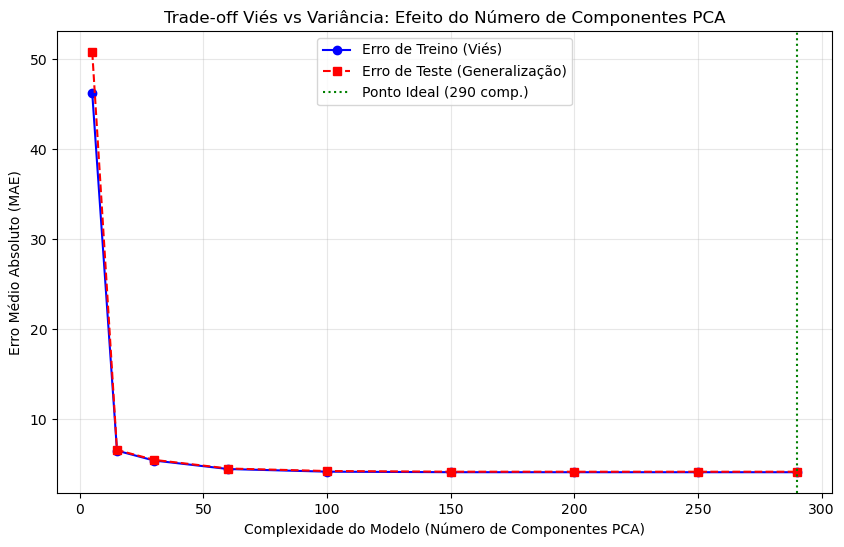


Melhor modelo salvo com sucesso no dicionário 'modelos'!


In [20]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import PolynomialFeatures, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
# from sklearn.metrics import mean_absolute_error

# Garante que a estrutura principal existe
modelos.setdefault('NL_regularizada', {})

grau_poly = 2

lista_componentes_pca = [5, 15, 30, 60, 100, 150, 200, 250, 290] 

# Listas para armazenar o histórico de erros para o gráfico
historico_mae_treino = []
historico_mae_teste = []
melhor_mae_teste = float('inf')
melhor_modelo_pipeline = None
melhor_n_comp = 0
melhor_RR_medias = None
melhor_MAE_medias = None
melhor_RR_sessao = None
melhor_MAE_sessao = None

# Criação do Pipeline de Pré-processamento 
polynomial_preprocessor_global_NL = ColumnTransformer(
    [
        (
            "num_poly",
            Pipeline([
                ("poly", PolynomialFeatures(degree=grau_poly, include_bias=False)),
                ("scaler", StandardScaler()),
            ]),
            X_train_global.columns,
        ),
    ],
    verbose_feature_names_out=False,
)

print(f"Iniciando varredura do PCA... Testando {len(lista_componentes_pca)} configurações.\n")

# LOOP DE TREINAMENTO E AVALIAÇÃO
for n_comp in lista_componentes_pca:
    
    NL_standard_global = Pipeline([
        ("preprocess", polynomial_preprocessor_global_NL),
        ("pca", PCA(n_components=n_comp)), 
        ("model", Ridge(alpha=1.0))
    ])
    
    NL_standard_global.fit(X_train_global, y_train_global)
    
    # Calcula Erro de Treino (Viés)
    y_pred_treino = NL_standard_global.predict(X_train_global)
    mae_treino_A = mean_absolute_error(y_train_global['u_a_k-1'], y_pred_treino[:, 0])
    mae_treino_B = mean_absolute_error(y_train_global['u_b_k-1'], y_pred_treino[:, 1])
    mae_treino_C = mean_absolute_error(y_train_global['u_c_k-1'], y_pred_treino[:, 2])
    mae_treino_medio = np.mean([mae_treino_A, mae_treino_B, mae_treino_C])
    historico_mae_treino.append(mae_treino_medio)

    # Calcula Erro de Teste (Variância/Generalização)
    num_sessoes = len(lista_X_test)
    RR_sessao_atual = np.zeros((num_sessoes, 3))
    MAE_sessao_atual = np.zeros((num_sessoes, 3)) 

    for a in range(num_sessoes):
        X_test_atual = lista_X_test[a]
        y_test_atual = lista_y_test[a]
        
        y_pred_teste = NL_standard_global.predict(X_test_atual)
        
        # Cálculos de RR
        simples_A = X_test_atual['u_dc_k-2'] * X_test_atual['d_a_k-2']
        simples_B = X_test_atual['u_dc_k-2'] * X_test_atual['d_b_k-2']
        simples_C = X_test_atual['u_dc_k-2'] * X_test_atual['d_c_k-2']
        RR_sessao_atual[a, 0] = ML_comp_simples(y_test_atual['u_a_k-1'], y_pred_teste[:, 0], simples_A)
        RR_sessao_atual[a, 1] = ML_comp_simples(y_test_atual['u_b_k-1'], y_pred_teste[:, 1], simples_B)
        RR_sessao_atual[a, 2] = ML_comp_simples(y_test_atual['u_c_k-1'], y_pred_teste[:, 2], simples_C)

        # Cálculos de MAE
        MAE_sessao_atual[a, 0] = mean_absolute_error(y_test_atual['u_a_k-1'], y_pred_teste[:, 0])
        MAE_sessao_atual[a, 1] = mean_absolute_error(y_test_atual['u_b_k-1'], y_pred_teste[:, 1])
        MAE_sessao_atual[a, 2] = mean_absolute_error(y_test_atual['u_c_k-1'], y_pred_teste[:, 2])

    MAE_medias_atual = np.mean(MAE_sessao_atual, axis=0)
    mae_teste_medio = np.mean(MAE_medias_atual) 
    historico_mae_teste.append(mae_teste_medio)
    
    variancia_exp = np.sum(NL_standard_global.named_steps['pca'].explained_variance_ratio_) * 100
    print(f"PCA c/ {n_comp:>3} comp. | Var Explicada: {variancia_exp:>6.2f}% | MAE Treino: {mae_treino_medio:.4f} | MAE Teste: {mae_teste_medio:.4f}")

    # Salva os dados do melhor modelo encontrado
    if mae_teste_medio < melhor_mae_teste:
        melhor_mae_teste = mae_teste_medio
        melhor_modelo_pipeline = NL_standard_global
        melhor_n_comp = n_comp
        melhor_RR_medias = np.mean(RR_sessao_atual, axis=0)
        melhor_MAE_medias = MAE_medias_atual
        melhor_RR_sessao = RR_sessao_atual
        melhor_MAE_sessao = MAE_sessao_atual

print(f"\nMelhor configuração encontrada: {melhor_n_comp} componentes do PCA.")

# Gráficos
plt.figure(figsize=(10, 6))
plt.plot(lista_componentes_pca, historico_mae_treino, marker='o', linestyle='-', color='blue', label='Erro de Treino (Viés)')
plt.plot(lista_componentes_pca, historico_mae_teste, marker='s', linestyle='--', color='red', label='Erro de Teste (Generalização)')

plt.axvline(x=melhor_n_comp, color='green', linestyle=':', label=f'Ponto Ideal ({melhor_n_comp} comp.)')

plt.title('Trade-off Viés vs Variância: Efeito do Número de Componentes PCA')
plt.xlabel('Complexidade do Modelo (Número de Componentes PCA)')
plt.ylabel('Erro Médio Absoluto (MAE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


modelos['NL_regularizada']['Global'] = {
    'Modelo': melhor_modelo_pipeline,
    'Grau_Polinomial': grau_poly,
    'Componentes_PCA': melhor_n_comp,
    'RR_sessao': melhor_RR_sessao,
    'RR_Geral_A': melhor_RR_medias[0],
    'RR_Geral_B': melhor_RR_medias[1],
    'RR_Geral_C': melhor_RR_medias[2],
    'MAE_sessao': melhor_MAE_sessao,
    'MAE_Geral_A': melhor_MAE_medias[0],
    'MAE_Geral_B': melhor_MAE_medias[1],
    'MAE_Geral_C': melhor_MAE_medias[2]
}
print("\nMelhor modelo salvo com sucesso no dicionário 'modelos'!")

### Resultados dos Modelos Não Lineares Sem Regularização

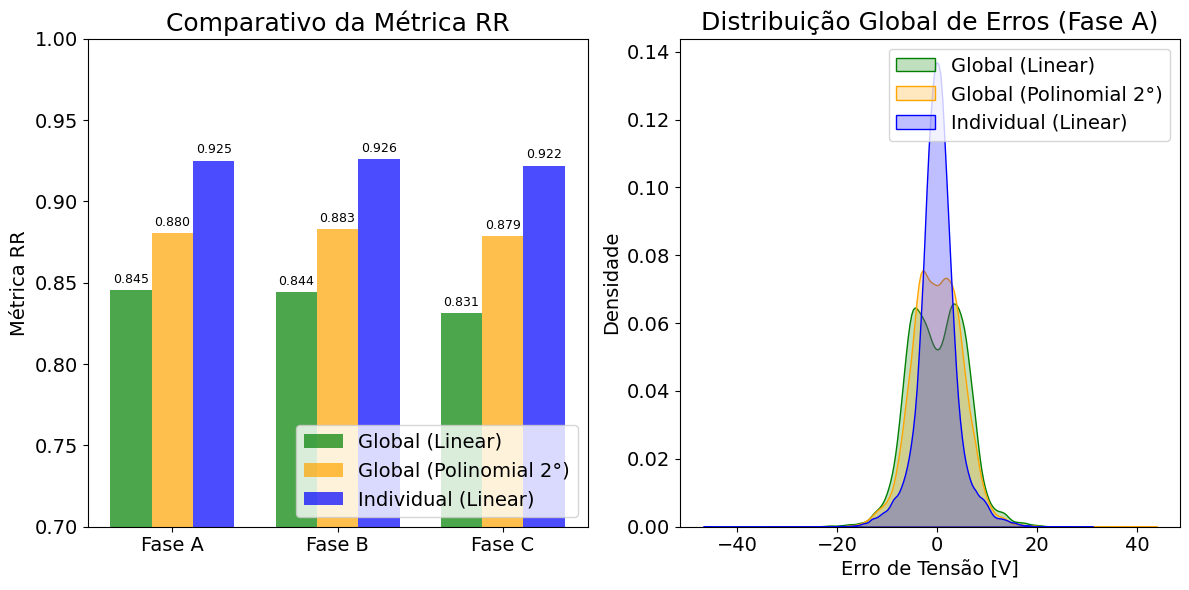

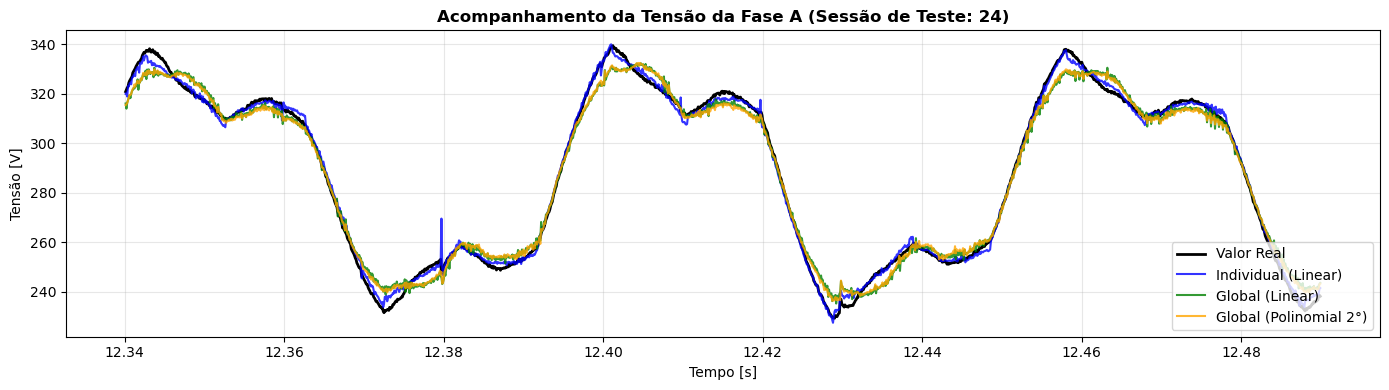

In [21]:
# Métricas médias RR do dicionário
rr_global_RL = [
    modelos['RL']['Global']['RR_Geral_A'],
    modelos['RL']['Global']['RR_Geral_B'],
    modelos['RL']['Global']['RR_Geral_C']
]

rr_global_NL = [
    modelos['NL']['Global']['RR_Geral_A'],
    modelos['NL']['Global']['RR_Geral_B'],
    modelos['NL']['Global']['RR_Geral_C']
]

rr_indiv_RL = [
    modelos['RL']['Individual']['RR_Geral_A'],
    modelos['RL']['Individual']['RR_Geral_B'],
    modelos['RL']['Individual']['RR_Geral_C']
]

# Agrupando os erros de todas as sessões para a curva de distribuição (Fase A)
erros_globais_RL_A = []
erros_globais_NL_A = []
erros_indivs_RL_A = []

num_sessoes = len(dados_modelo['X_teste'])

for a in range(num_sessoes):
    y_real_A = dados_modelo['y_teste'][a]['u_a_k-1'].values
    
    # Previsões da sessão atual
    pred_g_RL = modelos['RL']['Global']['Modelo'].predict(dados_modelo['X_teste'][a])[:, 0]
    pred_g_NL = modelos['NL']['Global']['Modelo'].predict(dados_modelo['X_teste'][a])[:, 0]
    pred_i_RL = modelos['RL']['Individual']['Previsoes'][a][:, 0]
    
    # Calculando os erros (Real - Estimado)
    erros_globais_RL_A.extend(y_real_A - pred_g_RL)
    erros_globais_NL_A.extend(y_real_A - pred_g_NL)
    erros_indivs_RL_A.extend(y_real_A - pred_i_RL)

# Preparação dos Dados Específicos 
X_test_val = dados_modelo['X_teste'][sessao_teste]
timestamp = X_test_val['timestamp'].values
y_teste_A_val = dados_modelo['y_teste'][sessao_teste]['u_a_k-1'].values

# Previsões apenas da sessão específica
y_pred_A_global_RL_val = modelos['RL']['Global']['Modelo'].predict(X_test_val)[:, 0]
y_pred_A_global_NL_val = modelos['NL']['Global']['Modelo'].predict(X_test_val)[:, 0]
y_pred_A_indiv_RL_val = modelos['RL']['Individual']['Previsoes'][sessao_teste][:, 0]

# Plotagem dos Gráficos
x_label = ['Fase A', 'Fase B', 'Fase C']
x = np.arange(len(x_label)) 
width = 0.25 

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# plt.suptitle("Métricas de Performance Gerais (Todas as Sessões)", fontweight='bold')

# Barras Lado a Lado (RR) 
ax[0].set_title("Comparativo da Métrica RR", fontsize = 18)
ax[0].set_ylabel("Métrica RR", fontsize = 14)
ax[0].set_ylim(0.7) 
ax[0].tick_params(axis='both', labelsize=14)
barras_global = ax[0].bar(x - width, rr_global_RL, width, alpha=0.7, label="Global (Linear)", color=cor_val_global_RL)
barras_global_NL = ax[0].bar(x, rr_global_NL, width, alpha=0.7, label="Global (Polinomial 2°)", color=cor_val_global_NL)
barras_indiv = ax[0].bar(x + width, rr_indiv_RL, width, alpha=0.7, label="Individual (Linear)", color=cor_val_indiv_RL)

ax[0].bar_label(barras_global, fmt='%.3f', padding=3, fontsize=9)
ax[0].bar_label(barras_global_NL, fmt='%.3f', padding=3, fontsize=9)
ax[0].bar_label(barras_indiv, fmt='%.3f', padding=3, fontsize=9)

ax[0].set_xticks(x)
ax[0].set_xticklabels(x_label)
ax[0].legend(loc='lower right', fontsize = 14)

# Distribuição de Erros (KDE) 
sns.kdeplot(erros_globais_RL_A, fill=True, color=cor_val_global_RL, label="Global (Linear)", ax=ax[1])
sns.kdeplot(erros_globais_NL_A, fill=True, color=cor_val_global_NL, label="Global (Polinomial 2°)", ax=ax[1])
sns.kdeplot(erros_indivs_RL_A, fill=True, color=cor_val_indiv_RL, label="Individual (Linear)", ax=ax[1])

ax[1].set_title("Distribuição Global de Erros (Fase A)", fontsize = 18)
ax[1].set_ylabel("Densidade", fontsize = 14)
ax[1].set_xlabel("Erro de Tensão [V]", fontsize = 14)
ax[1].tick_params(axis='both', labelsize=14)
ax[1].legend(loc='upper right', fontsize = 14)

plt.tight_layout()
plt.savefig('Métricas NL')

plt.show()

# Predição no Tempo (Sessão Específica)
plt.figure(figsize=(14, 4))

plt.title(f"Acompanhamento da Tensão da Fase A (Sessão de Teste: {sessao_teste})", fontweight='bold')
plt.plot(timestamp, y_teste_A_val, color=cor_val_real, label="Valor Real", linewidth=2)
plt.plot(timestamp, y_pred_A_indiv_RL_val, color=cor_val_indiv_RL, label='Individual (Linear)', alpha=0.8)
plt.plot(timestamp, y_pred_A_global_RL_val, color=cor_val_global_RL, label='Global (Linear)', alpha=0.8)
plt.plot(timestamp, y_pred_A_global_NL_val, color=cor_val_global_NL, label='Global (Polinomial 2°)', alpha=0.8)

plt.ylabel('Tensão [V]')
plt.xlabel('Tempo [s]')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Regressão Polinomial Regularizada

### Modelo Global (Único)

### Modelo Individual

In [22]:
modelos.setdefault('NL_regularizada', {})

num_sessoes = len(X)
grau_poly = 2
lista_componentes_pca = [5, 15, 30, 60, 100, 150, 200, 250, 290]

historico_mae_treino_ind = []
historico_mae_teste_ind = []

melhor_mae_teste_ind = float('inf')
melhor_n_comp_ind = 0
melhor_modelos_independentes = None
melhor_previsoes_por_sessao = None
melhor_RR_sessao_ind = None
melhor_MAE_sessao_ind = None
melhor_RR_medias_ind = None
melhor_MAE_medias_ind = None

tolerancia_melhoria = 0.05
modelo_travado = False 

print(f"Iniciando varredura do PCA (Modelos Individuais)... Testando {len(lista_componentes_pca)} configurações.\n")

for n_comp in lista_componentes_pca:
    
    mae_treino_todas_sessoes = []
    RR_sessao_atual = np.zeros((num_sessoes, 3))
    MAE_sessao_atual = np.zeros((num_sessoes, 3))
    modelos_independentes_atual = []
    previsoes_sessao_atual = []
    variancia_explicada_sessoes = []
    
    for a in range(num_sessoes):
        X_train, X_test, y_train, y_test = train_test_split(X[a], y[a], test_size=0.3, shuffle=False)
        
        polynomial_preprocessor_sessao = ColumnTransformer(
            [
                (
                    "num_poly",
                    Pipeline([
                        ("poly", PolynomialFeatures(degree=grau_poly, include_bias=False)),
                        ("scaler", StandardScaler()),
                    ]),
                    X_train.columns,
                ),
            ],
            verbose_feature_names_out=False,
        )
        
        NL_sessao_reg = Pipeline([
            ("preprocess", polynomial_preprocessor_sessao),
            ("pca", PCA(n_components=n_comp)), 
            ("model", Ridge(alpha=1.0))
        ])
        
        NL_sessao_reg.fit(X_train, y_train)
        modelos_independentes_atual.append(NL_sessao_reg)
        
        var_exp = np.sum(NL_sessao_reg.named_steps['pca'].explained_variance_ratio_) * 100
        variancia_explicada_sessoes.append(var_exp)
        
        y_pred_treino = NL_sessao_reg.predict(X_train)
        mae_treino_A = mean_absolute_error(y_train['u_a_k-1'], y_pred_treino[:, 0])
        mae_treino_B = mean_absolute_error(y_train['u_b_k-1'], y_pred_treino[:, 1])
        mae_treino_C = mean_absolute_error(y_train['u_c_k-1'], y_pred_treino[:, 2])
        mae_treino_medio_sessao = np.mean([mae_treino_A, mae_treino_B, mae_treino_C])
        mae_treino_todas_sessoes.append(mae_treino_medio_sessao)
        
        y_pred_teste = NL_sessao_reg.predict(X_test)
        previsoes_sessao_atual.append(y_pred_teste)
        
        RR_sessao_atual[a, 0] = ML_comp_simples(y_test['u_a_k-1'], y_pred_teste[:, 0], dados_modelo['y_simples_A'][a])
        RR_sessao_atual[a, 1] = ML_comp_simples(y_test['u_b_k-1'], y_pred_teste[:, 1], dados_modelo['y_simples_B'][a])
        RR_sessao_atual[a, 2] = ML_comp_simples(y_test['u_c_k-1'], y_pred_teste[:, 2], dados_modelo['y_simples_C'][a])
        
        MAE_sessao_atual[a, 0] = mean_absolute_error(y_test['u_a_k-1'], y_pred_teste[:, 0])
        MAE_sessao_atual[a, 1] = mean_absolute_error(y_test['u_b_k-1'], y_pred_teste[:, 1])
        MAE_sessao_atual[a, 2] = mean_absolute_error(y_test['u_c_k-1'], y_pred_teste[:, 2])

    mae_treino_medio_global = np.mean(mae_treino_todas_sessoes)
    historico_mae_treino_ind.append(mae_treino_medio_global)
    
    MAE_medias_atual = np.mean(MAE_sessao_atual, axis=0)
    mae_teste_medio_global = np.mean(MAE_medias_atual)
    historico_mae_teste_ind.append(mae_teste_medio_global)
    
    var_exp_media = np.mean(variancia_explicada_sessoes)
    
    print(f"PCA c/ {n_comp:>3} comp. | Var Explicada Média: {var_exp_media:>6.2f}% | MAE Treino: {mae_treino_medio_global:.4f} | MAE Teste: {mae_teste_medio_global:.4f}")
    
    if not modelo_travado:
        if (melhor_mae_teste_ind - mae_teste_medio_global) > tolerancia_melhoria:
            melhor_mae_teste_ind = mae_teste_medio_global
            melhor_n_comp_ind = n_comp
            
            melhor_modelos_independentes = modelos_independentes_atual
            melhor_previsoes_por_sessao = previsoes_sessao_atual
            melhor_RR_sessao_ind = RR_sessao_atual
            melhor_MAE_sessao_ind = MAE_sessao_atual
            
            melhor_RR_medias_ind = np.mean(RR_sessao_atual, axis=0)
            melhor_MAE_medias_ind = MAE_medias_atual
        else:
            modelo_travado = True
            print(f" ---> Ganho irrelevante. Travando a escolha no modelo de {melhor_n_comp_ind} componentes para poupar tempo de inferência!\n")

print(f"\nMelhor configuração Individual encontrada: {melhor_n_comp_ind} componentes do PCA.")


modelos['NL_regularizada']['Individual'] = {
    'Modelos': melhor_modelos_independentes,
    'Grau_Polinomial': grau_poly,
    'Componentes_PCA': melhor_n_comp_ind,
    'Previsoes': melhor_previsoes_por_sessao,
    'RR_sessao': melhor_RR_sessao_ind,
    'RR_Geral_A': melhor_RR_medias_ind[0],
    'RR_Geral_B': melhor_RR_medias_ind[1],
    'RR_Geral_C': melhor_RR_medias_ind[2],
    'MAE_sessao': melhor_MAE_sessao_ind,
    'MAE_Geral_A': melhor_MAE_medias_ind[0],
    'MAE_Geral_B': melhor_MAE_medias_ind[1],
    'MAE_Geral_C': melhor_MAE_medias_ind[2]
}

print("-" * 34, "Resultados da Melhor Configuração (Individuais)", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {melhor_RR_medias_ind[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {melhor_RR_medias_ind[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {melhor_RR_medias_ind[2]:.4f}")
print("-" * 133)
print(f"{' ' * 40} Média MAE das sessões da Fase A: {melhor_MAE_medias_ind[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {melhor_MAE_medias_ind[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {melhor_MAE_medias_ind[2]:.4f}")
print("-" * 133)
print(f"\nMelhores modelos individuais (PCA: {melhor_n_comp_ind}) salvos com sucesso em modelos['NL_regularizada']['Individual']!")

Iniciando varredura do PCA (Modelos Individuais)... Testando 9 configurações.

PCA c/   5 comp. | Var Explicada Média:  94.49% | MAE Treino: 23.4213 | MAE Teste: 26.2887
PCA c/  15 comp. | Var Explicada Média:  99.90% | MAE Treino: 3.8319 | MAE Teste: 4.8755
PCA c/  30 comp. | Var Explicada Média:  99.99% | MAE Treino: 2.0377 | MAE Teste: 3.1524
PCA c/  60 comp. | Var Explicada Média: 100.00% | MAE Treino: 1.7775 | MAE Teste: 2.7726
PCA c/ 100 comp. | Var Explicada Média: 100.00% | MAE Treino: 1.7465 | MAE Teste: 2.7547
 ---> Ganho irrelevante. Travando a escolha no modelo de 60 componentes para poupar tempo de inferência!

PCA c/ 150 comp. | Var Explicada Média: 100.00% | MAE Treino: 1.7459 | MAE Teste: 2.7543
PCA c/ 200 comp. | Var Explicada Média: 100.00% | MAE Treino: 1.7459 | MAE Teste: 2.7543
PCA c/ 250 comp. | Var Explicada Média: 100.00% | MAE Treino: 1.7459 | MAE Teste: 2.7543
PCA c/ 290 comp. | Var Explicada Média: 100.00% | MAE Treino: 1.7459 | MAE Teste: 2.7543

Melhor conf

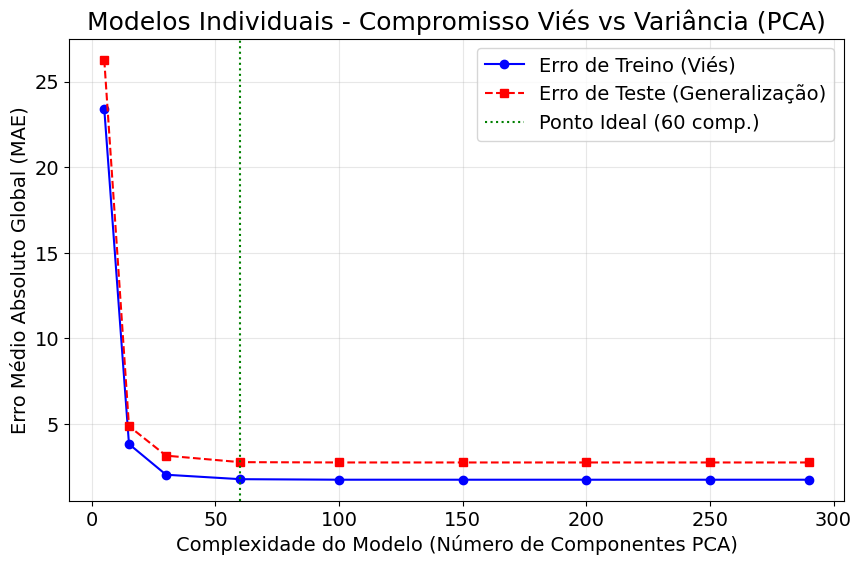

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(lista_componentes_pca, historico_mae_treino_ind, marker='o', linestyle='-', color='blue', label='Erro de Treino (Viés)')
plt.plot(lista_componentes_pca, historico_mae_teste_ind, marker='s', linestyle='--', color='red', label='Erro de Teste (Generalização)')

plt.axvline(x=melhor_n_comp_ind, color='green', linestyle=':', label=f'Ponto Ideal ({melhor_n_comp_ind} comp.)')

plt.title('Modelos Individuais - Compromisso Viés vs Variância (PCA)', fontsize = 18)
plt.xlabel('Complexidade do Modelo (Número de Componentes PCA)', fontsize = 14)

plt.ylabel('Erro Médio Absoluto Global (MAE)', fontsize = 14)
plt.legend(fontsize = 14)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.savefig('Ajuste NL')
plt.show()

O gráfico acima que mostra que o modelo não sofre de overfitting, mas a margem de melhoria no MAE não é justificada pelo aumento da complexidade do modelo.

A análise acima mostra que grande parte do sinal ainda é modelado pela lógica simples de $u_{dc(k-2}*d_{a(k-2)}$ mas a adição de parâmetros não confunde o algoritmo atrapalhando no treino. Uma vez que há muito menos features do que informação válida a ser modelada.


In [24]:
modelos['NL_regularizada']['Individual']['Componentes_PCA']

60

## Florestas Aleatórias

### Modelo Global (Sem ajuste de hiperparâmetros)

In [25]:
from sklearn.ensemble import RandomForestRegressor

modelos.setdefault('RF_Comp_Scheme', {})

ideal_A_train = X_train_global['u_dc_k-2'] * X_train_global['d_a_k-2']
ideal_B_train = X_train_global['u_dc_k-2'] * X_train_global['d_b_k-2']
ideal_C_train = X_train_global['u_dc_k-2'] * X_train_global['d_c_k-2']

y_train_erro = pd.DataFrame({
    'u_a_k-1': y_train_global['u_a_k-1'] - ideal_A_train,
    'u_b_k-1': y_train_global['u_b_k-1'] - ideal_B_train,
    'u_c_k-1': y_train_global['u_c_k-1'] - ideal_C_train
})

rf_model_comp = RandomForestRegressor(
    n_estimators=50, 
    max_depth=15, 
    random_state=42,
    n_jobs=-1 
)

rf_model_comp.fit(X_train_global, y_train_erro)
print("Treinamento concluído! Avaliando nas 48 sessões de teste...\n")

num_sessoes = len(lista_X_test)
RR_sessao_rf_comp = np.zeros((num_sessoes, 3))
MAE_sessao_rf_comp = np.zeros((num_sessoes, 3))

for a in range(num_sessoes):
    X_test_atual = lista_X_test[a]
    y_test_atual = lista_y_test[a]
    
    y_pred_erro = rf_model_comp.predict(X_test_atual)
    
    simples_A = X_test_atual['u_dc_k-2'] * X_test_atual['d_a_k-2']
    simples_B = X_test_atual['u_dc_k-2'] * X_test_atual['d_b_k-2']
    simples_C = X_test_atual['u_dc_k-2'] * X_test_atual['d_c_k-2']

    y_pred_final = np.zeros_like(y_pred_erro)
    y_pred_final[:, 0] = simples_A + y_pred_erro[:, 0]
    y_pred_final[:, 1] = simples_B + y_pred_erro[:, 1]
    y_pred_final[:, 2] = simples_C + y_pred_erro[:, 2]

    RR_sessao_rf_comp[a, 0] = ML_comp_simples(y_test_atual['u_a_k-1'], y_pred_final[:, 0], simples_A)
    RR_sessao_rf_comp[a, 1] = ML_comp_simples(y_test_atual['u_b_k-1'], y_pred_final[:, 1], simples_B)
    RR_sessao_rf_comp[a, 2] = ML_comp_simples(y_test_atual['u_c_k-1'], y_pred_final[:, 2], simples_C)

    MAE_sessao_rf_comp[a, 0] = mean_absolute_error(y_test_atual['u_a_k-1'], y_pred_final[:, 0])
    MAE_sessao_rf_comp[a, 1] = mean_absolute_error(y_test_atual['u_b_k-1'], y_pred_final[:, 1])
    MAE_sessao_rf_comp[a, 2] = mean_absolute_error(y_test_atual['u_c_k-1'], y_pred_final[:, 2])


RR_medias_rf_comp = np.mean(RR_sessao_rf_comp, axis=0)
MAE_medias_rf_comp = np.mean(MAE_sessao_rf_comp, axis=0)

print("-" * 34, "Desempenho Geral (Random Forest COMPENSAÇÃO)", "-" * 34)
print(f"{' ' * 40} Média RR das sessões da Fase A: {RR_medias_rf_comp[0]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase B: {RR_medias_rf_comp[1]:.4f}")
print(f"{' ' * 40} Média RR das sessões da Fase C: {RR_medias_rf_comp[2]:.4f}")
print("-" * 114)
print(f"{' ' * 40} Média MAE das sessões da Fase A: {MAE_medias_rf_comp[0]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase B: {MAE_medias_rf_comp[1]:.4f}")
print(f"{' ' * 40} Média MAE das sessões da Fase C: {MAE_medias_rf_comp[2]:.4f}")
print("-" * 114)

importancias = rf_model_comp.feature_importances_
df_importancias = pd.DataFrame({
    'Feature': X_train_global.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\nPesos que a Floresta considerou para prever o ERRO)")
print(df_importancias.head(10))

modelos['RF_Comp_Scheme']['Global'] = {
    'Modelo_Erro': rf_model_comp,
    'Importancias': df_importancias,
    'RR_sessao': RR_sessao_rf_comp,
    'RR_Geral_A': RR_medias_rf_comp[0],
    'RR_Geral_B': RR_medias_rf_comp[1],
    'RR_Geral_C': RR_medias_rf_comp[2],
    'MAE_sessao': MAE_sessao_rf_comp,
    'MAE_Geral_A': MAE_medias_rf_comp[0],
    'MAE_Geral_B': MAE_medias_rf_comp[1],
    'MAE_Geral_C': MAE_medias_rf_comp[2]
}

Treinamento concluído! Avaliando nas 48 sessões de teste...

---------------------------------- Desempenho Geral (Random Forest COMPENSAÇÃO) ----------------------------------
                                         Média RR das sessões da Fase A: 0.9975
                                         Média RR das sessões da Fase B: 0.9978
                                         Média RR das sessões da Fase C: 0.9977
------------------------------------------------------------------------------------------------------------------
                                         Média MAE das sessões da Fase A: 0.4296
                                         Média MAE das sessões da Fase B: 0.4102
                                         Média MAE das sessões da Fase C: 0.4159
------------------------------------------------------------------------------------------------------------------

Pesos que a Floresta considerou para prever o ERRO)
    Feature  Importancia
8   i_b_k-1     0.406320
7   i_a_

### Modelo Global (Regularizado)

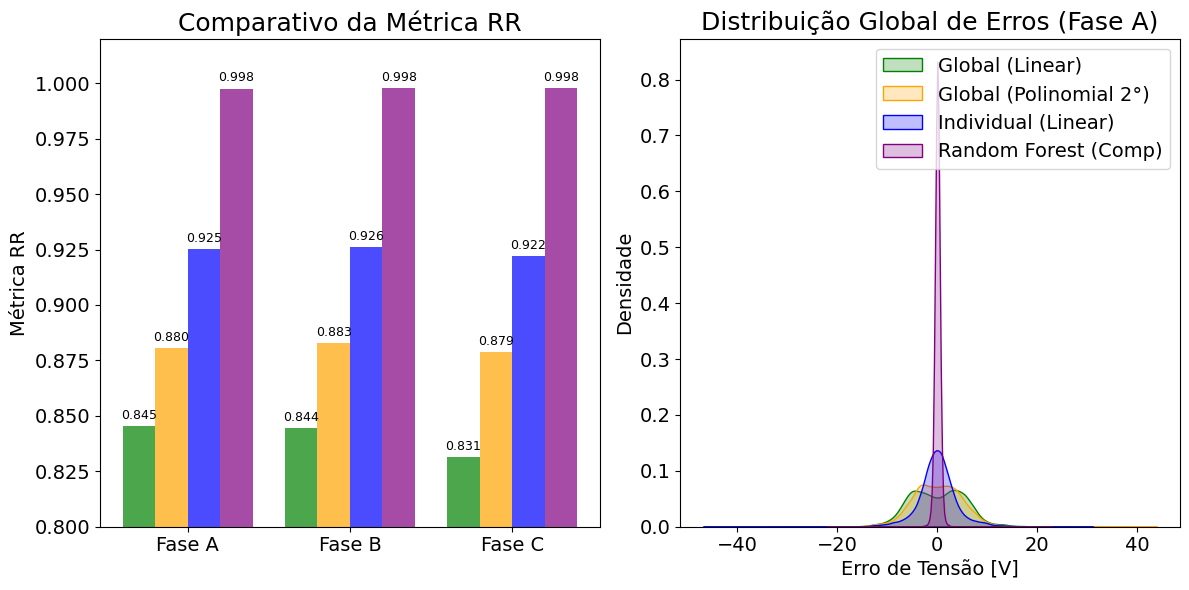

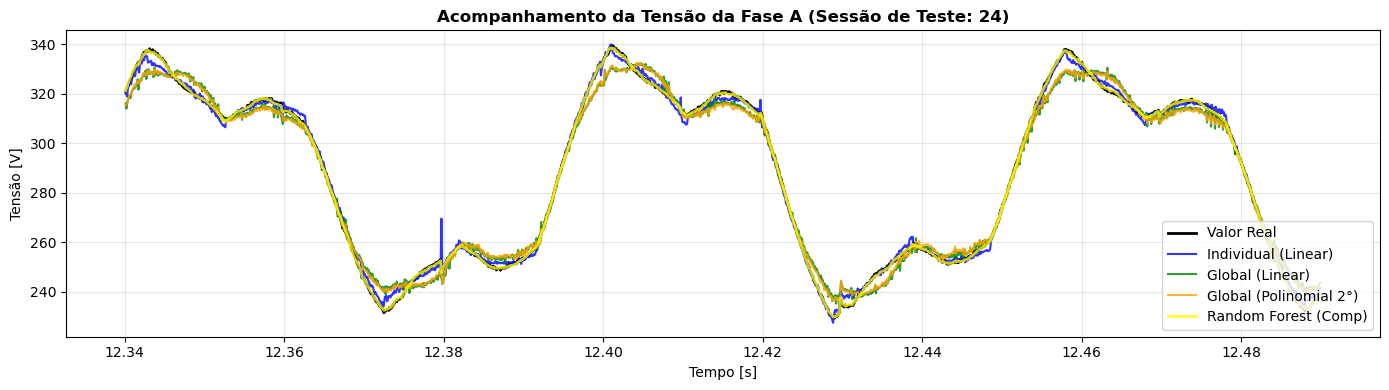

In [26]:
cor_val_rf_comp = 'purple' 

rr_global_RL = [
    modelos['RL']['Global']['RR_Geral_A'],
    modelos['RL']['Global']['RR_Geral_B'],
    modelos['RL']['Global']['RR_Geral_C']
]

rr_global_NL = [
    modelos['NL']['Global']['RR_Geral_A'],
    modelos['NL']['Global']['RR_Geral_B'],
    modelos['NL']['Global']['RR_Geral_C']
]

rr_indiv_RL = [
    modelos['RL']['Individual']['RR_Geral_A'],
    modelos['RL']['Individual']['RR_Geral_B'],
    modelos['RL']['Individual']['RR_Geral_C']
]

rr_global_RF_comp = [
    modelos['RF_Comp_Scheme']['Global']['RR_Geral_A'],
    modelos['RF_Comp_Scheme']['Global']['RR_Geral_B'],
    modelos['RF_Comp_Scheme']['Global']['RR_Geral_C']
]

erros_globais_RL_A = []
erros_globais_NL_A = []
erros_indivs_RL_A = []
erros_globais_RF_comp_A = [] 

num_sessoes = len(dados_modelo['X_teste'])

for a in range(num_sessoes):
    y_real_A = dados_modelo['y_teste'][a]['u_a_k-1'].values
    
    pred_g_RL = modelos['RL']['Global']['Modelo'].predict(dados_modelo['X_teste'][a])[:, 0]
    pred_g_NL = modelos['NL']['Global']['Modelo'].predict(dados_modelo['X_teste'][a])[:, 0]
    pred_i_RL = modelos['RL']['Individual']['Previsoes'][a][:, 0]
    
    pred_erro_RF = modelos['RF_Comp_Scheme']['Global']['Modelo_Erro'].predict(dados_modelo['X_teste'][a])
    simples_A = dados_modelo['X_teste'][a]['u_dc_k-2'] * dados_modelo['X_teste'][a]['d_a_k-2']
    pred_g_RF_comp = simples_A + pred_erro_RF[:, 0]
    
    erros_globais_RL_A.extend(y_real_A - pred_g_RL)
    erros_globais_NL_A.extend(y_real_A - pred_g_NL)
    erros_indivs_RL_A.extend(y_real_A - pred_i_RL)
    erros_globais_RF_comp_A.extend(y_real_A - pred_g_RF_comp) 


X_test_val = dados_modelo['X_teste'][sessao_teste]
timestamp = X_test_val['timestamp'].values

y_teste_A_val = dados_modelo['y_teste'][sessao_teste]['u_a_k-1'].values
y_teste_B_val = dados_modelo['y_teste'][sessao_teste]['u_b_k-1'].values
y_teste_C_val = dados_modelo['y_teste'][sessao_teste]['u_c_k-1'].values

y_pred_A_global_RL_val = modelos['RL']['Global']['Modelo'].predict(X_test_val)[:, 0]
y_pred_A_global_NL_val = modelos['NL']['Global']['Modelo'].predict(X_test_val)[:, 0]
y_pred_A_indiv_RL_val = modelos['RL']['Individual']['Previsoes'][sessao_teste][:, 0]
pred_erro_RF_val = modelos['RF_Comp_Scheme']['Global']['Modelo_Erro'].predict(X_test_val)

simples_A_val = X_test_val['u_dc_k-2'] * X_test_val['d_a_k-2']
simples_B_val = X_test_val['u_dc_k-2'] * X_test_val['d_b_k-2']
simples_C_val = X_test_val['u_dc_k-2'] * X_test_val['d_c_k-2']

y_pred_A_global_RF_comp_val = simples_A_val + pred_erro_RF_val[:, 0]
y_pred_B_global_RF_comp_val = simples_B_val + pred_erro_RF_val[:, 1]
y_pred_C_global_RF_comp_val = simples_C_val + pred_erro_RF_val[:, 2]


x_label = ['Fase A', 'Fase B', 'Fase C']
x = np.arange(len(x_label)) 
width = 0.20 

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# plt.suptitle("Métricas de Performance Gerais (Todas as Sessões)", fontweight='bold')

ax[0].set_title("Comparativo da Métrica RR", fontsize = 18)
ax[0].set_ylabel("Métrica RR", fontsize = 14)
ax[0].tick_params(axis='both', labelsize=14)
ax[0].set_ylim(0.8, 1.02)

barras_global = ax[0].bar(x - 1.5*width, rr_global_RL, width, alpha=0.7, label="Global (Linear)", color=cor_val_global_RL)
barras_global_NL = ax[0].bar(x - 0.5*width, rr_global_NL, width, alpha=0.7, label="Global (Polinomial 2°)", color=cor_val_global_NL)
barras_indiv = ax[0].bar(x + 0.5*width, rr_indiv_RL, width, alpha=0.7, label="Individual (Linear)", color=cor_val_indiv_RL)
barras_rf_comp = ax[0].bar(x + 1.5*width, rr_global_RF_comp, width, alpha=0.7, label="Random Forest (Comp)", color=cor_val_rf_comp)

ax[0].bar_label(barras_global, fmt='%.3f', padding=3, fontsize=9)
ax[0].bar_label(barras_global_NL, fmt='%.3f', padding=3, fontsize=9)
ax[0].bar_label(barras_indiv, fmt='%.3f', padding=3, fontsize=9)
ax[0].bar_label(barras_rf_comp, fmt='%.3f', padding=3, fontsize=9)

ax[0].set_xticks(x)
ax[0].set_xticklabels(x_label)

sns.kdeplot(erros_globais_RL_A, fill=True, color=cor_val_global_RL, label="Global (Linear)", ax=ax[1])
sns.kdeplot(erros_globais_NL_A, fill=True, color=cor_val_global_NL, label="Global (Polinomial 2°)", ax=ax[1])
sns.kdeplot(erros_indivs_RL_A, fill=True, color=cor_val_indiv_RL, label="Individual (Linear)", ax=ax[1])
sns.kdeplot(erros_globais_RF_comp_A, fill=True, color=cor_val_rf_comp, label="Random Forest (Comp)", ax=ax[1])

ax[1].set_title("Distribuição Global de Erros (Fase A)", fontsize =18)
ax[1].set_ylabel("Densidade", fontsize =14)
ax[1].set_xlabel("Erro de Tensão [V]", fontsize =14)
ax[1].tick_params(axis='both', labelsize=14)
ax[1].legend(loc='upper right', fontsize = 14)

plt.tight_layout()
plt.savefig('comp_final')
plt.show()

plt.figure(figsize=(14, 4))

plt.title(f"Acompanhamento da Tensão da Fase A (Sessão de Teste: {sessao_teste})", fontweight='bold')
plt.plot(timestamp, y_teste_A_val, color=cor_val_real, label="Valor Real", linewidth=2)
plt.plot(timestamp, y_pred_A_indiv_RL_val, color=cor_val_indiv_RL, label='Individual (Linear)', alpha=0.8)
plt.plot(timestamp, y_pred_A_global_RL_val, color=cor_val_global_RL, label='Global (Linear)', alpha=0.8)
plt.plot(timestamp, y_pred_A_global_NL_val, color=cor_val_global_NL, label='Global (Polinomial 2°)', alpha=0.8)
plt.plot(timestamp, y_pred_A_global_RF_comp_val, color='yellow', label='Random Forest (Comp)', alpha=0.8, linewidth=2) 

plt.ylabel('Tensão [V]')
plt.xlabel('Tempo [s]')
# plt.xlim(12.34,12.3425)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

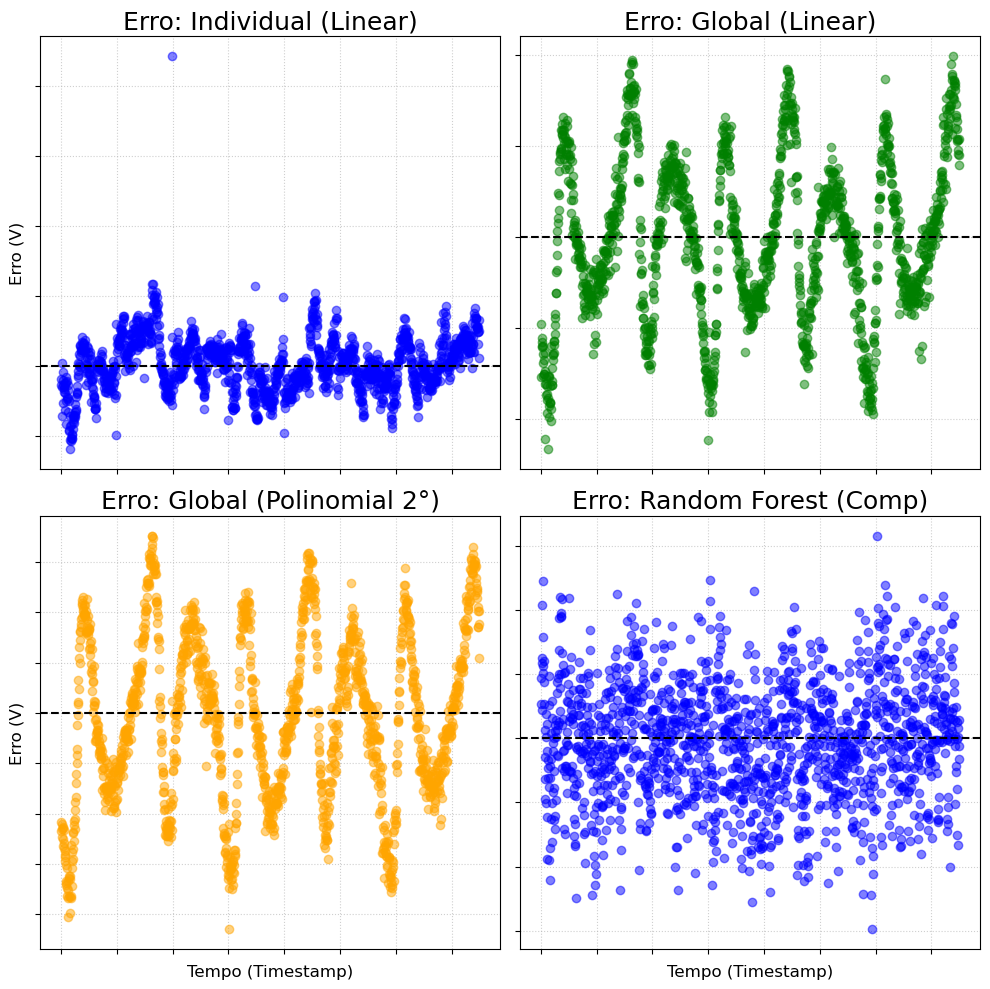

In [27]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharex=True)

axes = axes.flatten()


axes[0].plot(timestamp, y_pred_A_indiv_RL_val - y_teste_A_val, 'o', color=cor_val_indiv_RL, alpha=0.5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5) # Linha de referência no zero
axes[0].set_title('Erro: Individual (Linear)', fontsize = 18)
axes[0].set_ylabel('Erro (V)', fontsize = 12)
axes[0].set_yticklabels([])
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(timestamp, y_pred_A_global_RL_val - y_teste_A_val, 'o', color=cor_val_global_RL, alpha=0.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Erro: Global (Linear)', fontsize = 18)
axes[1].set_yticklabels([])
axes[1].grid(True, linestyle=':', alpha=0.6)

axes[2].plot(timestamp, y_pred_A_global_NL_val - y_teste_A_val, 'o', color=cor_val_global_NL, alpha=0.5)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[2].set_title('Erro: Global (Polinomial 2°)', fontsize = 18)
axes[2].set_ylabel('Erro (V)', fontsize = 12)
axes[2].set_yticklabels([])
axes[2].set_xlabel('Tempo (Timestamp)', fontsize = 12) # Adicionado pois este também está na parte de baixo
axes[2].grid(True, linestyle=':', alpha=0.6)

axes[3].plot(timestamp, y_pred_A_global_RF_comp_val - y_teste_A_val, 'o', color='blue', alpha=0.5)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[3].set_title('Erro: Random Forest (Comp)', fontsize = 18)
axes[3].set_xlabel('Tempo (Timestamp)', fontsize = 12)
axes[3].set_xticklabels([])
axes[3].set_yticklabels([])
axes[3].grid(True, linestyle=':', alpha=0.6)

plt.savefig('erros')
plt.tight_layout()

plt.show()

Há uma menor regularidade dos erros no modelo RandomForestRegressor, indicando uma modelagem que conseguiu captar a maioria da dinâmica do sistema


/tmp/ipykernel_273181/2469752498.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias.head(10), x='Importancia', y='Feature', palette='viridis')


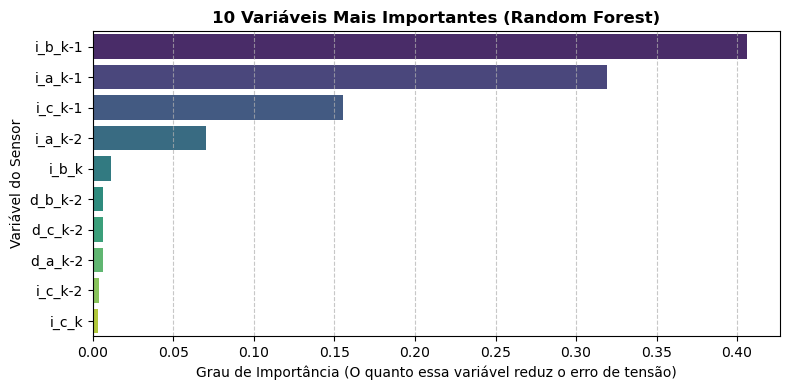

In [28]:

df_importancias = modelos['RF_Comp_Scheme']['Global']['Importancias']

plt.figure(figsize=(8, 4))
sns.barplot(data=df_importancias.head(10), x='Importancia', y='Feature', palette='viridis')

plt.title("10 Variáveis Mais Importantes (Random Forest)", fontweight='bold')
plt.xlabel("Grau de Importância (O quanto essa variável reduz o erro de tensão)")
plt.ylabel("Variável do Sensor")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('corr_erro')
plt.show()

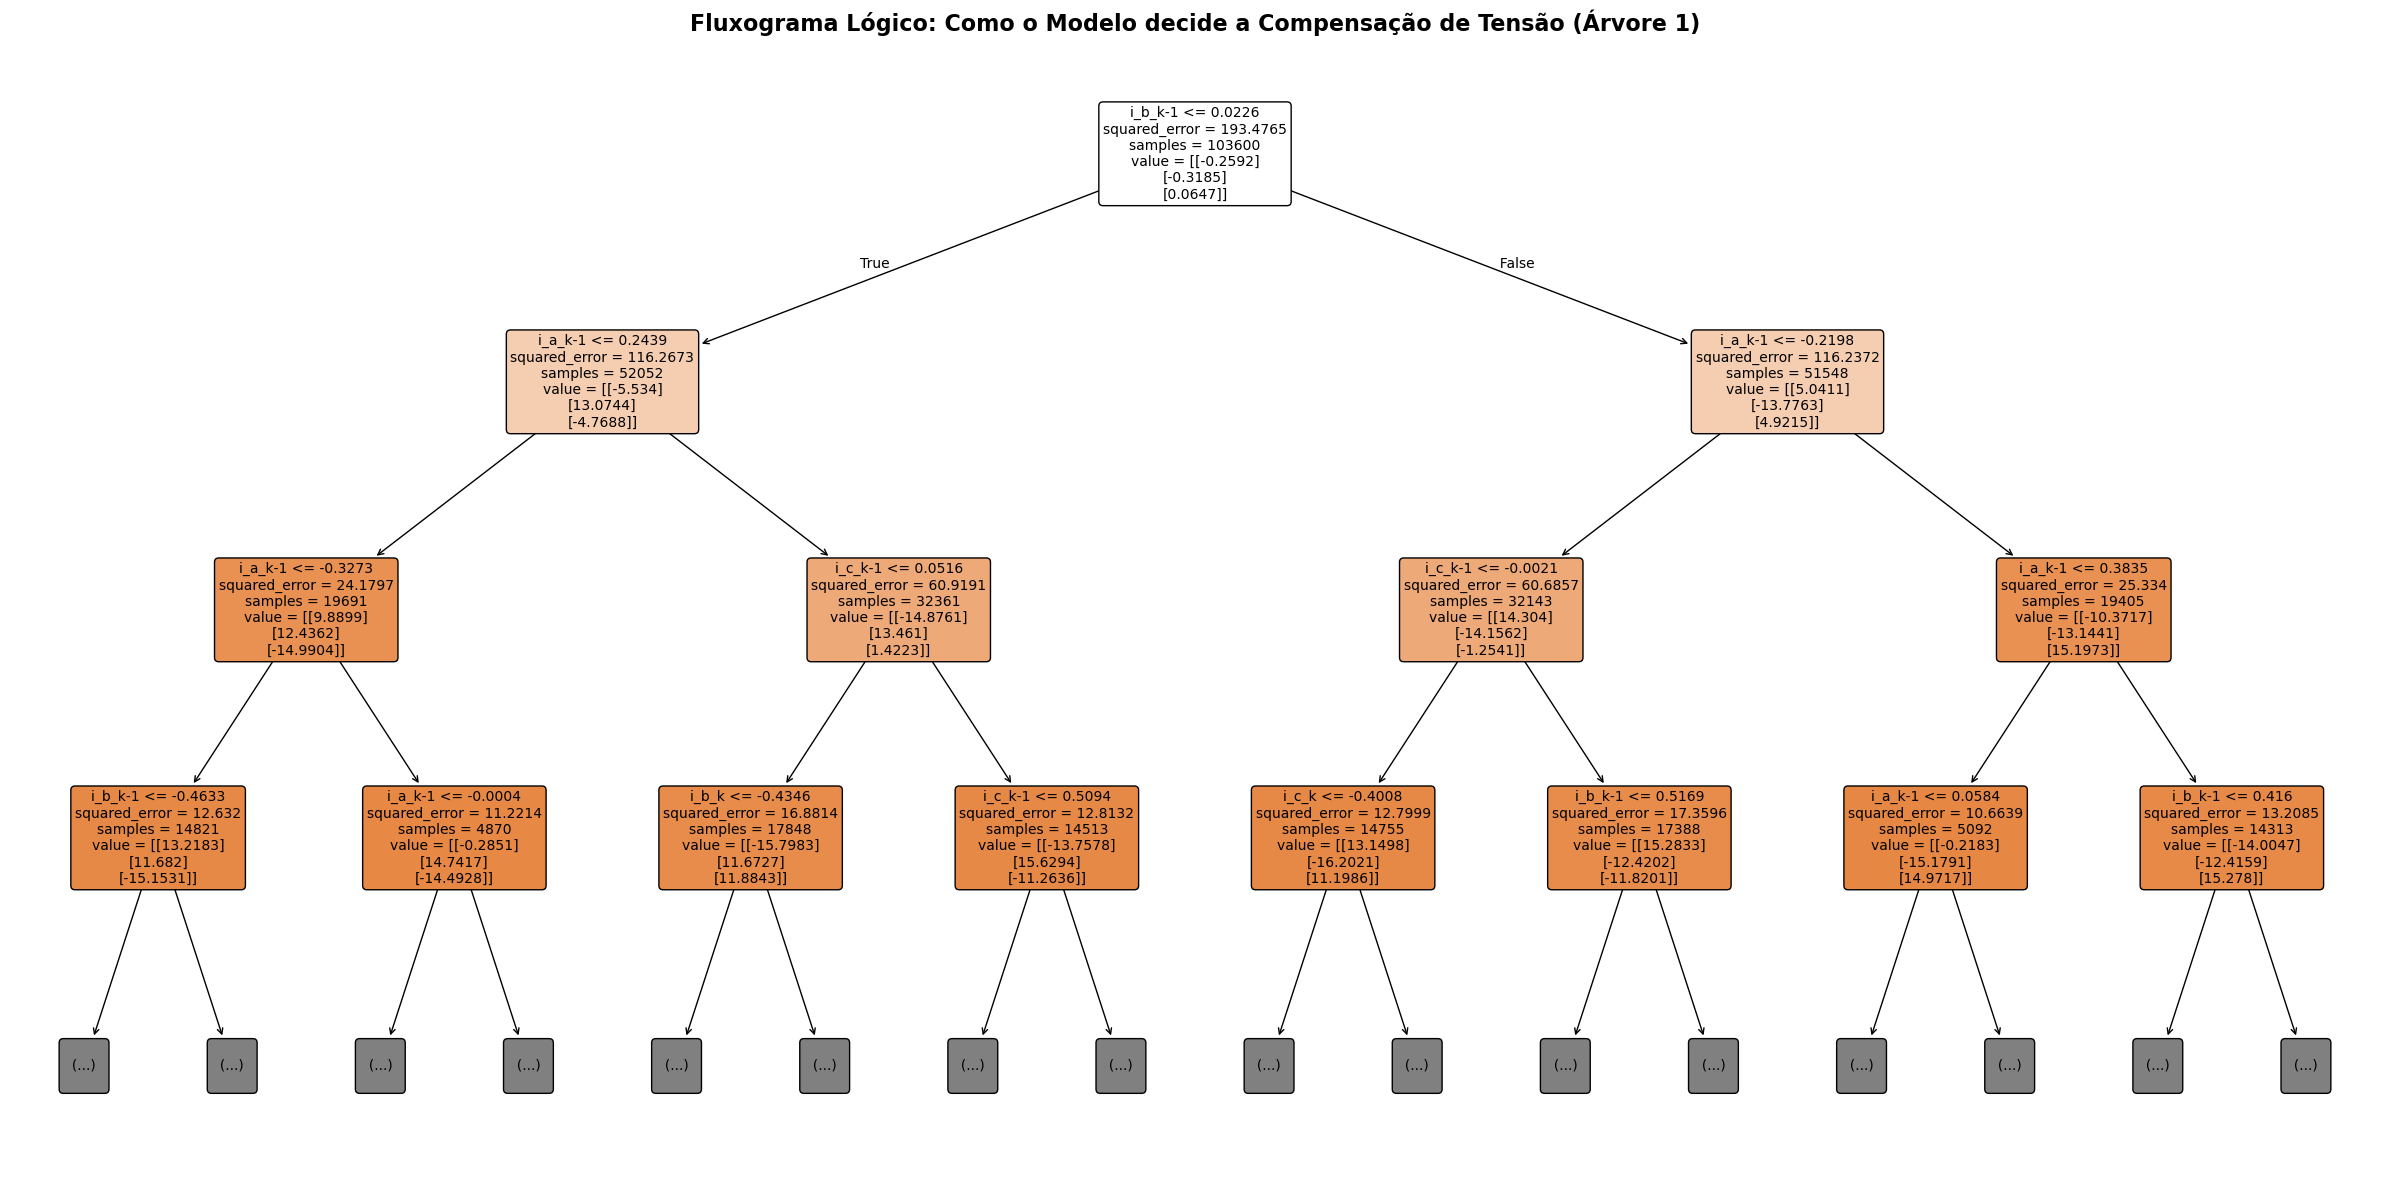

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

primeira_arvore = modelos['RF_Comp_Scheme']['Global']['Modelo_Erro'].estimators_[0]

plt.figure(figsize=(24, 12)) 

plot_tree(primeira_arvore, 
          feature_names=X_train_global.columns, 
          max_depth=3, 
          filled=True, 
          rounded=True, 
          fontsize=10,
          precision=4)

plt.title("Fluxograma Lógico: Como o Modelo decide a Compensação de Tensão (Árvore 1)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

É interessante notar que assim como a téoria analítica, as decisões que mais influenciam na regressão são as corremtes. Devido ao fenômeno do tempo morto e do clampeamento do inversor

In [30]:
modelos['NL_regularizada']['Global']['Modelo']

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_poly', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [31]:
import time
import pickle


X_simulacao_dsp = lista_X_test[0].iloc[[0]]

num_iteracoes = 5000

def simular_hardware(nome_modelo, modelo, X_sim):

    tamanho_bytes = len(pickle.dumps(modelo))
    
    _ = modelo.predict(X_sim)
    
    inicio = time.perf_counter_ns()
    
    for _ in range(num_iteracoes):
        _ = modelo.predict(X_sim)
        
    fim = time.perf_counter_ns()
    
    tempo_medio_us = ((fim - inicio) / num_iteracoes) / 1000.0
    
    return tempo_medio_us, tamanho_bytes

resultados_hw = []

tempo_rl, mem_rl = simular_hardware(
    "L(Global)", 
    modelos['RL']['Global']['Modelo'], 
    X_simulacao_dsp
)
resultados_hw.append({
    'Modelo': 'Linear (RL Global)',
    'Tempo por Amostra (µs)': tempo_rl,
    'Uso de Memória (Bytes)': mem_rl,
    'Complexidade na CPU': '14 MACs (Multiplicações e Somas diretas)',
    'MAE Fase A (V)': modelos['RL']['Global']['MAE_Geral_A']
})

tempo_nl, mem_nl = simular_hardware(
    "(NL", 
    modelos['NL_regularizada']['Global']['Modelo'], 
    X_simulacao_dsp
)
resultados_hw.append({
    'Modelo': 'Não-Linear (Global Reg)',
    'Tempo por Amostra (µs)': tempo_nl,
    'Uso de Memória (Bytes)': mem_nl,
    'Complexidade na CPU': 'Expansão de 299 polinômios + 299 MACs',
    'MAE Fase A (V)': modelos['NL']['Global']['MAE_Geral_A']
})

tempo_rf, mem_rf = simular_hardware(
    "RF ", 
    modelos['RF_Comp_Scheme']['Global']['Modelo_Erro'], 
    X_simulacao_dsp
)
resultados_hw.append({
    'Modelo': 'Random Forest (Comp)',
    'Tempo por Amostra (µs)': tempo_rf,
    'Uso de Memória (Bytes)': mem_rf,
    'Complexidade na CPU': '50 Árvores, centenas de instruções IF/ELSE por ciclo',
    'MAE Fase A (V)': modelos['RF_Comp_Scheme']['Global']['MAE_Geral_A']
})

df_benchmark = pd.DataFrame(resultados_hw)

print("\n" + "="*85)
print(" RELATÓRIO (Controle a 10 kHz / 100 µs)")
print("="*85)

for index, row in df_benchmark.iterrows():
    print(f"Modelo: {row['Modelo']}")
    print(f"  -> Precisão (MAE Fase A):   {row['MAE Fase A (V)']:.4f} Volts")
    print(f"  -> Carga de Memória:        {row['Uso de Memória (Bytes)'] / 1024:.2f} KB")
    print(f"  -> Custo de CPU:            {row['Complexidade na CPU']}")
    print(f"  -> Tempo Python Estimado:   {row['Tempo por Amostra (µs)']:.2f} µs")
    print("-" * 85)

print("\nNota :")
print("* O tempo medido acima inclui o atraso nativo (overhead) da linguagem Python.")
print("* Quando programado em linguagem C (Microcontrolador), esses tempos caem drasticamente.")
print("* O limite físico de um controle a 10 kHz é uma janela de 100 µs para TUDO (Sensor + PI + IA).")


 RELATÓRIO (Controle a 10 kHz / 100 µs)
Modelo: Linear (RL Global)
  -> Precisão (MAE Fase A):   4.6082 Volts
  -> Carga de Memória:        1.49 KB
  -> Custo de CPU:            14 MACs (Multiplicações e Somas diretas)
  -> Tempo Python Estimado:   1823.31 µs
-------------------------------------------------------------------------------------
Modelo: Não-Linear (Global Reg)
  -> Precisão (MAE Fase A):   3.9523 Volts
  -> Carga de Memória:        703.08 KB
  -> Custo de CPU:            Expansão de 299 polinômios + 299 MACs
  -> Tempo Python Estimado:   5634.06 µs
-------------------------------------------------------------------------------------
Modelo: Random Forest (Comp)
  -> Precisão (MAE Fase A):   0.4296 Volts
  -> Carga de Memória:        95430.13 KB
  -> Custo de CPU:            50 Árvores, centenas de instruções IF/ELSE por ciclo
  -> Tempo Python Estimado:   32908.00 µs
-------------------------------------------------------------------------------------

Nota :
* O tempo 


 RELATÓRIO DE Compromisso (Baseline: Linear Global = 1.0x)
Modelo: Linear (RL Global)
  -> Erro MAE : 1.00x da base (4.6082 V)
  -> Memória  : 1.00x da base
  -> Tempo    : 1.00x da base
-------------------------------------------------------------------------------------
Modelo: Não-Linear (Global Reg)
  -> Erro MAE : 0.86x da base (3.9523 V)
  -> Memória  : 471.48x da base
  -> Tempo    : 3.09x da base
-------------------------------------------------------------------------------------
Modelo: Random Forest (Comp)
  -> Erro MAE : 0.09x da base (0.4296 V)
  -> Memória  : 63995.06x da base
  -> Tempo    : 18.05x da base
-------------------------------------------------------------------------------------


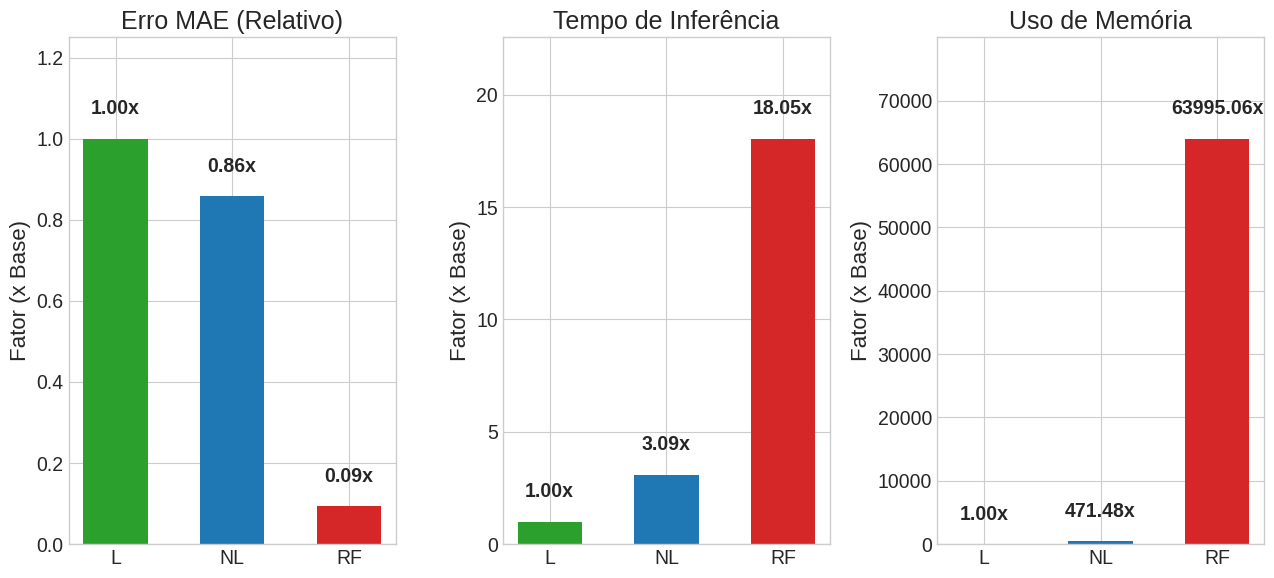

In [32]:
base_tempo = df_benchmark.loc[0, 'Tempo por Amostra (µs)']
base_memoria = df_benchmark.loc[0, 'Uso de Memória (Bytes)']
base_mae = df_benchmark.loc[0, 'MAE Fase A (V)']

df_benchmark['Tempo (Fator)'] = df_benchmark['Tempo por Amostra (µs)'] / base_tempo
df_benchmark['Memória (Fator)'] = df_benchmark['Uso de Memória (Bytes)'] / base_memoria
df_benchmark['Erro (Fator)'] = df_benchmark['MAE Fase A (V)'] / base_mae

print("\n" + "="*85)
print(" RELATÓRIO DE Compromisso (Baseline: Linear Global = 1.0x)")
print("="*85)

for index, row in df_benchmark.iterrows():
    print(f"Modelo: {row['Modelo']}")
    print(f"  -> Erro MAE : {row['Erro (Fator)']:.2f}x da base ({row['MAE Fase A (V)']:.4f} V)")
    print(f"  -> Memória  : {row['Memória (Fator)']:.2f}x da base")
    print(f"  -> Tempo    : {row['Tempo (Fator)']:.2f}x da base")
    print("-" * 85)

plt.style.use('seaborn-v0_8-whitegrid')

plt.rc('font', size=14)          
plt.rc('axes', titlesize=18, labelsize=16) 
plt.rc('xtick', labelsize=14)    
plt.rc('ytick', labelsize=14)    

fig, axes = plt.subplots(1, 3, figsize=(13, 6))

cores = ['#2ca02c', '#1f77b4', '#d62728'] 
modelos_nomes = ['L','NL','RF']

def autolabel(ax, valores):
    max_y = max(valores)
    for i, v in enumerate(valores):
        ax.text(i, v + (max_y * 0.05), f"{v:.2f}x", 
                ha='center', va='bottom', fontweight='bold', fontsize=14)
    ax.set_ylim(0, max_y * 1.25)

largura_barra = 0.55

axes[0].bar(modelos_nomes, df_benchmark['Erro (Fator)'], color=cores, width=largura_barra)
axes[0].set_title('Erro MAE (Relativo)', fontsize=18)
axes[0].set_ylabel('Fator (x Base)', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
autolabel(axes[0], df_benchmark['Erro (Fator)'])

axes[1].bar(modelos_nomes, df_benchmark['Tempo (Fator)'], color=cores, width=largura_barra)
axes[1].set_title('Tempo de Inferência', fontsize=18)
axes[1].set_ylabel('Fator (x Base)', fontsize=16)
autolabel(axes[1], df_benchmark['Tempo (Fator)'])

axes[2].bar(modelos_nomes, df_benchmark['Memória (Fator)'], color=cores, width=largura_barra)
axes[2].set_title('Uso de Memória', fontsize=18)
axes[2].set_ylabel('Fator (x Base)', fontsize=16)
autolabel(axes[2], df_benchmark['Memória (Fator)'])

plt.tight_layout()
plt.savefig('compro')
plt.show()

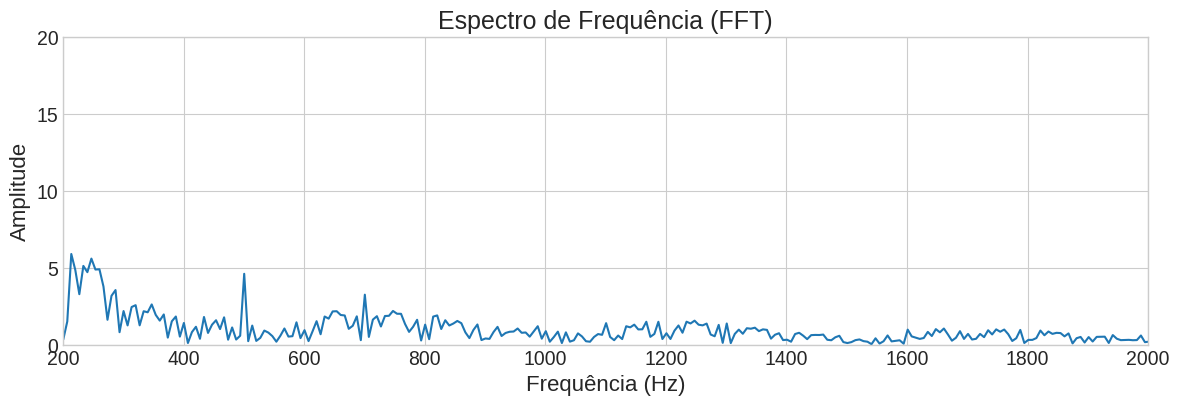

In [33]:

sinal = dados_modelo['y_teste'][0]['u_a_k-1'] - dados_modelo['y_teste'][0]['u_b_k-1']
tempo = timestamp

N = len(tempo)                     
T = tempo[1] - tempo[0]            


yf = np.fft.fft(sinal)           
xf = np.fft.fftfreq(N, T)       

xf_positivo = xf[:N//2]
yf_magnitude = 2.0 / N * np.abs(yf[:N//2])

plt.figure(figsize=(14, 4))
plt.plot(xf_positivo, yf_magnitude)
plt.title('Espectro de Frequência (FFT)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.xlim(200, 2000) 
plt.ylim(0,20)

plt.show()

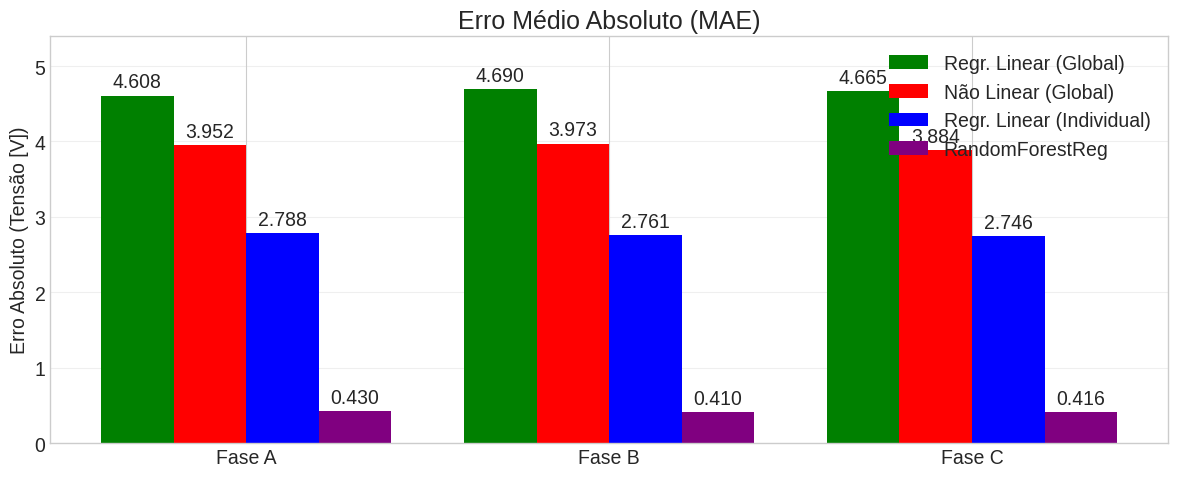

In [34]:
valores_MAE_simples = [
    mean_absolute_error(y_teste_A_val, y_simples_A_val),
    mean_absolute_error(y_teste_B_val, y_simples_B_val),
    mean_absolute_error(y_teste_C_val, y_simples_C_val)
]

valores_MAE_indiv_RL = [
    modelos['RL']['Individual']['MAE_Geral_A'],
    modelos['RL']['Individual']['MAE_Geral_B'],
    modelos['RL']['Individual']['MAE_Geral_C']
]

valores_MAE_global_RL = [
    modelos['RL']['Global']['MAE_Geral_A'],
    modelos['RL']['Global']['MAE_Geral_B'],
    modelos['RL']['Global']['MAE_Geral_C']
]

valores_MAE_RF = [
    modelos['RF_Comp_Scheme']['Global']['MAE_Geral_A'],
    modelos['RF_Comp_Scheme']['Global']['MAE_Geral_B'],
    modelos['RF_Comp_Scheme']['Global']['MAE_Geral_C']
]

valores_MAE_Global_NL = [
    modelos['NL']['Global']['MAE_Geral_A'],
    modelos['NL']['Global']['MAE_Geral_B'],
    modelos['NL']['Global']['MAE_Geral_C']
]

x_label = ['Fase A', 'Fase B', 'Fase C']
x_indices = np.arange(len(x_label))


largura = 0.2 

plt.figure(figsize=(12, 5))
plt.title(f"Erro Médio Absoluto (MAE)", fontsize = 18)
plt.ylabel("Erro Absoluto (Tensão [V])", fontsize=14)

barras_global  = plt.bar(x_indices - 1.5 * largura, valores_MAE_global_RL, largura, label="Regr. Linear (Global)", color=cor_val_global_RL)
barras_simples = plt.bar(x_indices - 0.5 * largura, valores_MAE_Global_NL, largura, label="Não Linear (Global)", color=cor_val_simples)
barras_indiv   = plt.bar(x_indices + 0.5 * largura, valores_MAE_indiv_RL, largura, label="Regr. Linear (Individual)", color=cor_val_indiv_RL)
barras_RF = plt.bar(x_indices + 1.5 * largura, valores_MAE_RF, largura, label="RandomForestReg", color='purple')

plt.xticks(x_indices, x_label)

plt.bar_label(barras_simples, fmt='%.3f', padding=3, fontsize=14)
plt.bar_label(barras_global, fmt='%.3f', padding=3, fontsize=14)
plt.bar_label(barras_indiv, fmt='%.3f', padding=3, fontsize=14)
plt.bar_label(barras_RF, fmt='%.3f', padding=3, fontsize=14)

ymax = max(max(valores_MAE_Global_NL), max(valores_MAE_global_RL), max(valores_MAE_indiv_RL), max(valores_MAE_RF))
plt.ylim(0, ymax * 1.15) 

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3) 
plt.tight_layout()
plt.tick_params(axis='x', labelsize=14)
plt.savefig('MAE Fase')
plt.show()

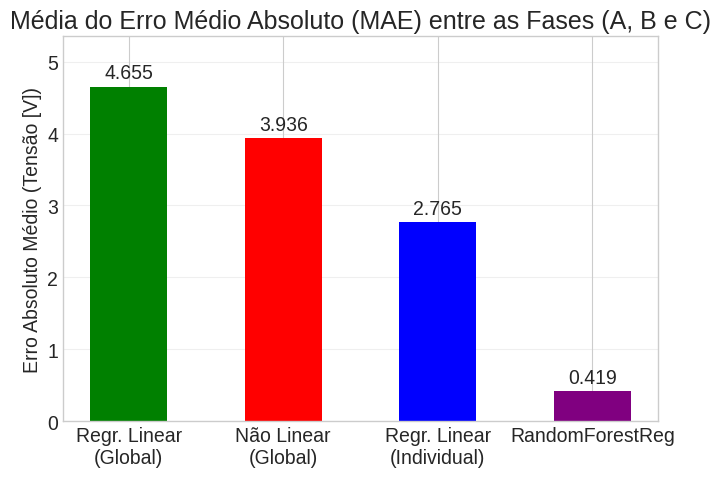

In [35]:

media_global_RL = np.mean(valores_MAE_global_RL)
media_Global_NL = np.mean(valores_MAE_Global_NL)
media_indiv_RL  = np.mean(valores_MAE_indiv_RL)
media_RF        = np.mean(valores_MAE_RF)


modelos_labels = [
    'Regr. Linear\n(Global)', 
    'Não Linear\n(Global)', 
    'Regr. Linear\n(Individual)', 
    'RandomForestReg'
]

medias_mae = [
    media_global_RL, 
    media_Global_NL, 
    media_indiv_RL, 
    media_RF
]

cores = [cor_val_global_RL, cor_val_simples, cor_val_indiv_RL, 'purple']

plt.figure(figsize=(7, 5)) 
plt.title("Média do Erro Médio Absoluto (MAE) entre as Fases (A, B e C)", fontsize = 18)
plt.ylabel("Erro Absoluto Médio (Tensão [V])", fontsize = 14)

barras = plt.bar(modelos_labels, medias_mae, color=cores, width=0.5)

plt.bar_label(barras, fmt='%.3f', padding=3, fontsize=14)

ymax = max(medias_mae)
plt.ylim(0, ymax * 1.15)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.yticks(fontsize =14)
plt.yticks(fontsize =14)
plt.tick_params(axis='x', labelsize=14)
plt.savefig('MAE_geral')
plt.show()